### Explanatory Data Analysis

* Author: Gina Nguyen

* Date: 03/05/2026

* Purpose: Explore the fincinal complaint dataset and extract any pattern or insights

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# 1. Overal exploration

In [19]:
import os
import duckdb

# Robust DuckDB path resolution: walk up to 4 levels and look for database/cfpb_complaints.duckdb
cwd = os.getcwd()
search_bases = []
base = cwd
db_path = None
for _ in range(4):
    search_bases.append(base)
    candidate = os.path.join(base, "database", "cfpb_complaints.duckdb")
    if os.path.exists(candidate):
        db_path = candidate
        break
    parent = os.path.dirname(base)
    if parent == base:
        break
    base = parent

if not db_path:
    raise FileNotFoundError(
        "DuckDB not found. Looked under these bases: " + ", ".join(search_bases)
    )

conn = duckdb.connect(db_path, read_only=True)
print(f"Connected to {db_path}")

Connected to /Users/ninhgiangnguyen/local_warehouse_pipeline/database/cfpb_complaints.duckdb


### 1.1 Head check 

In [20]:
# 1.1 Head check – basic preview

# Use the marts fact table as the main EDA source


def head_check(database, num_heads):
    df = conn.execute(f"""
        SELECT *
        FROM {database}
    """).df()

    row_count = conn.execute(f"""
        SELECT COUNT(*) AS n_rows
        FROM {database}
    """).df()

    print(f"Number of rows in {database}:")
    print(row_count)
    print(f"Number of columns in {database}:", len(df.columns.tolist()))
    print("Column list: ", df.columns.tolist())
    print("\nSample rows:")

    return df.iloc[:num_heads], df

In [21]:
head_fct_complaints, fct_complaints = head_check("marts.fct_complaints", 3)
head_fct_complaints

Number of rows in marts.fct_complaints:
   n_rows
0  415254
Number of columns in marts.fct_complaints: 23
Column list:  ['complaint_id', 'product', 'sub_product', 'issue', 'sub_issue', 'company', 'state', 'zip_code', 'submitted_via', 'company_response', 'company_public_response', 'date_received', 'date_sent_to_company', 'complaint_year', 'complaint_month', 'complaint_month_date', 'days_to_response', 'is_timely_response', 'is_disputed', 'has_narrative', 'consumer_consent_provided', 'complaint_what_happened', 'tags']

Sample rows:


,complaint_id,product,sub_product,issue,sub_issue,company,state,zip_code,submitted_via,company_response,company_public_response,date_received,date_sent_to_company,complaint_year,complaint_month,complaint_month_date,days_to_response,is_timely_response,is_disputed,has_narrative,consumer_consent_provided,complaint_what_happened,tags
0,10000604,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,JPMORGAN CHASE & CO.,MA,027XX,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent provided,This situation has been going on since my XXXX...,"Older American, Servicemember"
1,10001246,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Unauthorized transactions or other transaction...,None,JPMORGAN CHASE & CO.,IL,60616,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent not provided,,Servicemember
2,10001329,Credit card,General-purpose credit card or charge card,Trouble using your card,Can't use card to make purchases,JPMORGAN CHASE & CO.,CA,XXXXX,Web,Closed with explanation,None,2024-09-03,2024-09-03,2024,9,2024-09-01,0,True,<NA>,True,Consent provided,On XX/XX/year> I contacted JPMC customer servi...,None


In [22]:
head_dim_companies, dim_companies = head_check("marts.dim_companies", 5)
head_dim_companies

Number of rows in marts.dim_companies:
   n_rows
0      68
Number of columns in marts.dim_companies: 13
Column list:  ['company', 'total_complaints', 'disputed_complaints', 'timely_responses', 'complaints_with_narrative', 'pct_disputed', 'pct_timely', 'avg_days_to_response', 'median_days_to_response', 'min_days_to_response', 'max_days_to_response', 'first_complaint_date', 'last_complaint_date']

Sample rows:


,company,total_complaints,disputed_complaints,timely_responses,complaints_with_narrative,pct_disputed,pct_timely,avg_days_to_response,median_days_to_response,min_days_to_response,max_days_to_response,first_complaint_date,last_complaint_date
0,CAPITAL ONE FINANCIAL CORPORATION,75862,NaN,75858.0,75862.0,NaN,99.99,0.80,0.0,0,145,2023-01-01,2026-02-25
1,JPMORGAN CHASE & CO.,62803,NaN,62803.0,62803.0,NaN,100.00,0.71,0.0,0,136,2023-01-01,2026-02-20
2,WELLS FARGO & COMPANY,58599,NaN,58597.0,58599.0,NaN,100.00,0.93,0.0,0,239,2023-01-01,2026-02-24
3,"BANK OF AMERICA, NATIONAL ASSOCIATION",51114,NaN,50260.0,51114.0,NaN,98.33,0.91,0.0,0,408,2023-01-01,2026-02-26
4,"CITIBANK, N.A.",47144,NaN,47143.0,47144.0,NaN,100.00,1.52,0.0,0,121,2023-01-01,2026-02-22


In [23]:
head_agg_complaints_by_month, agg_complaints_by_month = head_check(
    "marts.agg_complaints_by_month", 5
)
head_agg_complaints_by_month

Number of rows in marts.agg_complaints_by_month:
   n_rows
0      38
Number of columns in marts.agg_complaints_by_month: 15
Column list:  ['complaint_month_date', 'year', 'month', 'total_complaints', 'unique_companies', 'unique_products', 'unique_states', 'timely_responses', 'pct_timely', 'disputed_complaints', 'pct_disputed', 'complaints_with_narrative', 'pct_with_narrative', 'avg_days_to_response', 'median_days_to_response']

Sample rows:


,complaint_month_date,year,month,total_complaints,unique_companies,unique_products,unique_states,timely_responses,pct_timely,disputed_complaints,pct_disputed,complaints_with_narrative,pct_with_narrative,avg_days_to_response,median_days_to_response
0,2026-02-01,2026,2,7356,38,11,56,7356.0,100.00,NaN,NaN,7356.0,100.0,0.14,0.0
1,2026-01-01,2026,1,16785,44,11,56,16784.0,99.99,NaN,NaN,16785.0,100.0,0.41,0.0
2,2025-12-01,2025,12,16117,49,11,56,16105.0,99.93,NaN,NaN,16117.0,100.0,1.11,0.0
3,2025-11-01,2025,11,13669,47,10,56,13657.0,99.91,NaN,NaN,13669.0,100.0,1.71,0.0
4,2025-10-01,2025,10,13479,47,11,56,13467.0,99.91,NaN,NaN,13479.0,100.0,1.73,0.0


In [24]:
head_agg_complaints_by_month, agg_complaints_by_month = head_check(
    "marts.agg_complaints_by_month", 5
)
head_agg_complaints_by_month

Number of rows in marts.agg_complaints_by_month:
   n_rows
0      38
Number of columns in marts.agg_complaints_by_month: 15
Column list:  ['complaint_month_date', 'year', 'month', 'total_complaints', 'unique_companies', 'unique_products', 'unique_states', 'timely_responses', 'pct_timely', 'disputed_complaints', 'pct_disputed', 'complaints_with_narrative', 'pct_with_narrative', 'avg_days_to_response', 'median_days_to_response']

Sample rows:


,complaint_month_date,year,month,total_complaints,unique_companies,unique_products,unique_states,timely_responses,pct_timely,disputed_complaints,pct_disputed,complaints_with_narrative,pct_with_narrative,avg_days_to_response,median_days_to_response
0,2026-02-01,2026,2,7356,38,11,56,7356.0,100.00,NaN,NaN,7356.0,100.0,0.14,0.0
1,2026-01-01,2026,1,16785,44,11,56,16784.0,99.99,NaN,NaN,16785.0,100.0,0.41,0.0
2,2025-12-01,2025,12,16117,49,11,56,16105.0,99.93,NaN,NaN,16117.0,100.0,1.11,0.0
3,2025-11-01,2025,11,13669,47,10,56,13657.0,99.91,NaN,NaN,13669.0,100.0,1.71,0.0
4,2025-10-01,2025,10,13479,47,11,56,13467.0,99.91,NaN,NaN,13479.0,100.0,1.73,0.0


In [25]:
head_dim_products, dim_products = head_check("marts.dim_products", 3)
head_dim_products

Number of rows in marts.dim_products:
   n_rows
0      90
Number of columns in marts.dim_products: 17
Column list:  ['product', 'sub_product', 'total_complaints', 'unique_companies', 'unique_states', 'timely_responses', 'pct_timely', 'disputed_complaints', 'pct_disputed', 'complaints_with_narrative', 'pct_with_narrative', 'avg_days_to_response', 'median_days_to_response', 'first_complaint_date', 'last_complaint_date', 'most_common_issue', 'most_complained_company']

Sample rows:


,product,sub_product,total_complaints,unique_companies,unique_states,timely_responses,pct_timely,disputed_complaints,pct_disputed,complaints_with_narrative,pct_with_narrative,avg_days_to_response,median_days_to_response,first_complaint_date,last_complaint_date,most_common_issue,most_complained_company
0,Checking or savings account,None,3.0,2,3,3.0,100.00,NaN,NaN,3.0,100.0,1.33,1.00,2024-03-13,2024-04-03,None,WELLS FARGO & COMPANY
1,Checking or savings account,None,120474.0,6,6,120025.0,99.63,NaN,NaN,120474.0,100.0,1.12,0.33,2023-01-01,2026-02-26,Managing an account,WELLS FARGO & COMPANY
2,Checking or savings account,CD (Certificate of Deposit),2621.0,42,54,2609.0,99.54,NaN,NaN,2621.0,100.0,1.47,0.00,2023-01-04,2026-02-20,Managing an account,GOLDMAN SACHS BANK USA


In [26]:
head_dim_states, dim_states = head_check("marts.dim_states", 3)
head_dim_states

Number of rows in marts.dim_states:
   n_rows
0      61
Number of columns in marts.dim_states: 22
Column list:  ['state', 'total_complaints', 'unique_companies', 'unique_products', 'unique_issues', 'unique_zip_codes', 'timely_responses', 'pct_timely', 'disputed_complaints', 'pct_disputed', 'complaints_with_narrative', 'pct_with_narrative', 'avg_days_to_response', 'median_days_to_response', 'min_days_to_response', 'max_days_to_response', 'first_complaint_date', 'last_complaint_date', 'most_common_product', 'most_common_issue', 'most_complained_company', 'most_common_submission_method']

Sample rows:


,state,total_complaints,unique_companies,unique_products,unique_issues,unique_zip_codes,timely_responses,pct_timely,disputed_complaints,pct_disputed,complaints_with_narrative,pct_with_narrative,avg_days_to_response,median_days_to_response,min_days_to_response,max_days_to_response,first_complaint_date,last_complaint_date,most_common_product,most_common_issue,most_complained_company,most_common_submission_method
0,CA,61156,51,14,82,1605,60967.0,99.69,NaN,NaN,61156.0,100.0,1.09,0.0,0,239,2023-01-01,2026-02-26,Checking or savings account,Managing an account,WELLS FARGO & COMPANY,Web
1,FL,45578,48,14,77,1077,45468.0,99.76,NaN,NaN,45578.0,100.0,1.06,0.0,0,148,2023-01-01,2026-02-25,Credit reporting or other personal consumer re...,Incorrect information on your report,CAPITAL ONE FINANCIAL CORPORATION,Web
2,TX,37437,48,14,78,1286,37357.0,99.79,NaN,NaN,37437.0,100.0,0.98,0.0,0,408,2023-01-01,2026-02-24,Checking or savings account,Managing an account,CAPITAL ONE FINANCIAL CORPORATION,Web


In [27]:
head_dim_issues, dim_issues = head_check("marts.dim_issues", 3)
head_dim_issues

Number of rows in marts.dim_issues:
   n_rows
0     374
Number of columns in marts.dim_issues: 18
Column list:  ['issue', 'sub_issue', 'total_complaints', 'unique_companies', 'unique_products', 'unique_states', 'timely_responses', 'pct_timely', 'disputed_complaints', 'pct_disputed', 'complaints_with_narrative', 'pct_with_narrative', 'avg_days_to_response', 'median_days_to_response', 'first_complaint_date', 'last_complaint_date', 'most_common_product', 'most_complained_company']

Sample rows:


,issue,sub_issue,total_complaints,unique_companies,unique_products,unique_states,timely_responses,pct_timely,disputed_complaints,pct_disputed,complaints_with_narrative,pct_with_narrative,avg_days_to_response,median_days_to_response,first_complaint_date,last_complaint_date,most_common_product,most_complained_company
0,Advertising,None,54.0,2,1,2,54.0,100.0,NaN,NaN,54.0,100.0,1.42,0.0,2023-01-18,2026-01-12,Prepaid card,"BANK OF AMERICA, NATIONAL ASSOCIATION"
1,Advertising,Changes in terms from what was offered or adve...,24.0,9,2,10,24.0,100.0,NaN,NaN,24.0,100.0,1.63,0.0,2023-02-02,2026-01-05,Prepaid card,"BANK OF AMERICA, NATIONAL ASSOCIATION"
2,Advertising,Confusing or misleading advertising about the ...,30.0,8,2,13,30.0,100.0,NaN,NaN,30.0,100.0,1.20,0.0,2023-01-18,2026-01-12,Prepaid card,"BANK OF AMERICA, NATIONAL ASSOCIATION"


In [28]:
head_dim_response_types, dim_response_types = head_check("marts.dim_response_types", 3)
head_dim_response_types

Number of rows in marts.dim_response_types:
   n_rows
0       5
Number of columns in marts.dim_response_types: 20
Column list:  ['company_response', 'total_complaints', 'unique_companies', 'unique_products', 'unique_states', 'timely_responses', 'pct_timely', 'disputed_complaints', 'pct_disputed', 'complaints_with_narrative', 'pct_with_narrative', 'avg_days_to_response', 'median_days_to_response', 'min_days_to_response', 'max_days_to_response', 'first_complaint_date', 'last_complaint_date', 'most_common_product', 'most_common_issue', 'most_complained_company']

Sample rows:


,company_response,total_complaints,unique_companies,unique_products,unique_states,timely_responses,pct_timely,disputed_complaints,pct_disputed,complaints_with_narrative,pct_with_narrative,avg_days_to_response,median_days_to_response,min_days_to_response,max_days_to_response,first_complaint_date,last_complaint_date,most_common_product,most_common_issue,most_complained_company
0,Closed with explanation,306974,65,14,61,306308.0,99.78,NaN,NaN,306974.0,100.0,1.08,0.0,0,239,2023-01-01,2026-02-25,Checking or savings account,Managing an account,CAPITAL ONE FINANCIAL CORPORATION
1,Closed with non-monetary relief,58572,34,14,59,58471.0,99.83,NaN,NaN,58572.0,100.0,1.12,0.0,0,133,2023-01-01,2026-02-24,Credit reporting or other personal consumer re...,Incorrect information on your report,"CITIBANK, N.A."
2,Closed with monetary relief,43159,45,14,58,42928.0,99.46,NaN,NaN,43159.0,100.0,0.90,0.0,0,103,2023-01-01,2026-02-23,Checking or savings account,Problem with a purchase shown on your statement,"BANK OF AMERICA, NATIONAL ASSOCIATION"


##### Data Landscape
We have **7 tables** totaling ~415K complaint records spanning **Jan 2023 – Feb 2026**.
The data is well-structured: one fact table, five pre-aggregated dimension tables, and one time-series table.

##### Tier 1 — Core (Must Use)

**`fct_complaints`** (415K rows, 23 cols) — *The backbone*
- Row-level complaint data. Contains the target variables: `is_timely_response`, `is_disputed`, `days_to_response`
- Has temporal columns (`date_received`, `complaint_year`, `complaint_month`) for trend analysis
- `complaint_what_happened` offers NLP/text analysis potential via `has_narrative` flag
- **Notable:** `is_disputed` appears mostly `<NA>` — needs investigation before use

**`agg_complaints_by_month`** (38 rows, 15 cols) — *Trend layer*
- Pre-aggregated monthly rollup. Ready to use for time series and trend visualizations
- `pct_disputed` is NaN across all rows — confirms disputed field is unreliable post-2023
- Complaint volume appears to be **growing YoY**, worth flagging


##### Tier 2 — Supporting (High Value)

**`dim_companies`** (68 rows, 13 cols)
-  68 companies (Chase, Capital One, Wells Fargo, BofA, Citi,...) 
- `pct_disputed` is NaN for all — consistent with fct_complaints issue
- `avg_days_to_response` is near 0 for most, suggesting most complaints are resolved same-day

**`dim_products`** (90 rows, 17 cols)
- Includes `most_common_issue` and `most_complained_company` — useful for quick profiling
- `Checking or savings account` dominates volume; sub-products add granularity
- Good for product-level segmentation analysis

**`dim_states`** (61 rows, 22 cols)
- 61 states (CA, TX, NY,...)
- Contains `most_common_product`, `most_common_issue`, `most_complained_company` per state
- Useful for geographic heatmaps and regional analysis


##### Tier 3 — Reference (Use When Needed)

**`dim_issues`** (374 rows, 18 cols)
- Most granular dimension — 374 issue/sub-issue combinations
- Useful for drill-down but too granular for top-level analysis
- Cross-reference with `fct_complaints` for root cause analysis

**`dim_response_types`** (5 rows, 20 cols)
- Only 5 response categories — very small, use as a filter/groupby rather than a full EDA subject
- "Closed with explanation" dominates (~307K / 74% of complaints)

##### How Tables Connect
| Join | Keys | Use Case |
|---|---|---|
| fct_complaints ↔ dim_companies | `company` | Enrich complaints with company-level metrics |
| fct_complaints ↔ dim_products | `product`, `sub_product` | Product-level complaint profiling |
| fct_complaints ↔ dim_states | `state` | Geographic analysis |
| fct_complaints ↔ dim_issues | `issue`, `sub_issue` | Root cause drill-down |
| fct_complaints ↔ dim_response_types | `company_response` | Response pattern analysis |


* sql here

In [29]:
df = conn.execute("""
    SELECT
        f.*,
        a.total_complaints           AS month_total_complaints,
        a.unique_companies           AS month_unique_companies,
        a.unique_products            AS month_unique_products,
        a.unique_states              AS month_unique_states,
        a.timely_responses           AS month_timely_responses,
        a.pct_timely                 AS month_pct_timely,
        a.complaints_with_narrative  AS month_complaints_with_narrative,
        a.pct_with_narrative         AS month_pct_with_narrative,
        a.avg_days_to_response       AS month_avg_days_to_response,
        a.median_days_to_response    AS month_median_days_to_response
        -- excluded: a.disputed_complaints, a.pct_disputed (unreliable post-2023)
    FROM marts.fct_complaints f
    LEFT JOIN marts.agg_complaints_by_month a
        ON f.complaint_year  = a.year
       AND f.complaint_month = a.month
""").df()

In [30]:
print(f"Number of rows in the master data: ", df.shape[0])
print(f"Number of columns in the master data: :", df.shape[1])
print("Column list: ", df.columns.tolist())
print("\nSample rows:")
df.iloc[:5]

Number of rows in the master data:  415254
Number of columns in the master data: : 33
Column list:  ['complaint_id', 'product', 'sub_product', 'issue', 'sub_issue', 'company', 'state', 'zip_code', 'submitted_via', 'company_response', 'company_public_response', 'date_received', 'date_sent_to_company', 'complaint_year', 'complaint_month', 'complaint_month_date', 'days_to_response', 'is_timely_response', 'is_disputed', 'has_narrative', 'consumer_consent_provided', 'complaint_what_happened', 'tags', 'month_total_complaints', 'month_unique_companies', 'month_unique_products', 'month_unique_states', 'month_timely_responses', 'month_pct_timely', 'month_complaints_with_narrative', 'month_pct_with_narrative', 'month_avg_days_to_response', 'month_median_days_to_response']

Sample rows:


,complaint_id,product,sub_product,issue,sub_issue,company,state,zip_code,submitted_via,company_response,company_public_response,date_received,date_sent_to_company,complaint_year,complaint_month,complaint_month_date,days_to_response,is_timely_response,is_disputed,has_narrative,consumer_consent_provided,complaint_what_happened,tags,month_total_complaints,month_unique_companies,month_unique_products,month_unique_states,month_timely_responses,month_pct_timely,month_complaints_with_narrative,month_pct_with_narrative,month_avg_days_to_response,month_median_days_to_response
0,11670046,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,CAPITAL ONE FINANCIAL CORPORATION,TX,75226,Web,Closed with explanation,None,2025-01-17,2025-01-17,2025,1,2025-01-01,0,True,<NA>,True,Consent not provided,,None,20156,47,11,57,20146.0,99.95,20156.0,100.0,0.55,0.0
1,11670239,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,CAPITAL ONE FINANCIAL CORPORATION,FL,34761,Web,Closed with explanation,None,2025-01-17,2025-01-17,2025,1,2025-01-01,0,True,<NA>,True,Consent provided,Despite successfully receiving checks from my ...,None,20156,47,11,57,20146.0,99.95,20156.0,100.0,0.55,0.0
2,11670270,Checking or savings account,Checking account,Managing an account,Problem making or receiving payments,CAPITAL ONE FINANCIAL CORPORATION,PA,17036,Web,Closed with explanation,None,2025-01-17,2025-01-17,2025,1,2025-01-01,0,True,<NA>,True,Consent not provided,,None,20156,47,11,57,20146.0,99.95,20156.0,100.0,0.55,0.0
3,11670333,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,CAPITAL ONE FINANCIAL CORPORATION,NY,10473,Web,Closed with explanation,None,2025-01-17,2025-01-17,2025,1,2025-01-01,0,True,<NA>,True,Consent not provided,,None,20156,47,11,57,20146.0,99.95,20156.0,100.0,0.55,0.0
4,11670386,Checking or savings account,Checking account,Managing an account,Funds not handled or disbursed as instructed,CAPITAL ONE FINANCIAL CORPORATION,CT,06320,Web,Closed with explanation,None,2025-01-17,2025-01-17,2025,1,2025-01-01,0,True,<NA>,True,Consent provided,On Tuesday XX/XX/year> my employer processed p...,None,20156,47,11,57,20146.0,99.95,20156.0,100.0,0.55,0.0


### 1.2 Column type

In [31]:
# 1.2 Column type – dtypes + high-level summary
print("Data types (from pandas):")
print(df.dtypes.to_frame("dtype"))

Data types (from pandas):
                                          dtype
complaint_id                             object
product                                  object
sub_product                              object
issue                                    object
sub_issue                                object
company                                  object
state                                    object
zip_code                                 object
submitted_via                            object
company_response                         object
company_public_response                  object
date_received                    datetime64[us]
date_sent_to_company             datetime64[us]
complaint_year                            int64
complaint_month                           int64
complaint_month_date             datetime64[us]
days_to_response                          int64
is_timely_response                         bool
is_disputed                             boolean
has_narrative 

In [32]:
summary = df.describe(include="all")
print("\nSummary statistics:")
summary


Summary statistics:


,complaint_id,product,sub_product,issue,sub_issue,company,state,zip_code,submitted_via,company_response,company_public_response,date_received,date_sent_to_company,complaint_year,complaint_month,complaint_month_date,days_to_response,is_timely_response,is_disputed,has_narrative,consumer_consent_provided,complaint_what_happened,tags,month_total_complaints,month_unique_companies,month_unique_products,month_unique_states,month_timely_responses,month_pct_timely,month_complaints_with_narrative,month_pct_with_narrative,month_avg_days_to_response,month_median_days_to_response
count,415254,415254,415251,415251,388450,415254,412584,415227,415254,415253,201660,415254,415254,415254.000000,415254.000000,415254,415254.000000,415254,0,415254,389128,415254,60043,415254.000000,415254.000000,415254.000000,415254.000000,415254.000000,415254.000000,415254.000000,415254.0,415254.000000,415254.0
unique,415254,14,58,90,208,68,61,17979,5,5,9,NaN,NaN,NaN,NaN,NaN,NaN,2,0,1,5,190898,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,11670046,Checking or savings account,General-purpose credit card or charge card,Managing an account,Deposits and withdrawals,CAPITAL ONE FINANCIAL CORPORATION,CA,XXXXX,Web,Closed with explanation,Company has responded to the consumer and the ...,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,True,Consent provided,,Older American,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,120474,103850,70702,26913,75862,61156,14031,379056,306974,201473,NaN,NaN,NaN,NaN,NaN,NaN,414229,NaN,415254,196237,219064,27626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-20 23:11:21.466283,2024-09-22 00:46:17.257292,2024.248963,6.208718,2024-09-06 06:50:01.447789,1.065924,NaN,NaN,NaN,NaN,NaN,NaN,11589.043352,46.700463,10.725900,55.735624,11563.602807,99.753265,11589.043352,100.0,1.066695,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-01 00:00:00,2023-01-01 00:00:00,2023.000000,1.000000,2023-01-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,7356.000000,38.000000,9.000000,54.000000,7356.000000,98.460000,7356.000000,100.0,0.140000,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-16 00:00:00,2023-12-17 00:00:00,2023.000000,3.000000,2023-12-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,9172.000000,45.000000,11.000000,55.000000,9167.000000,99.800000,9172.000000,100.0,0.550000,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-02 00:00:00,2024-11-03 00:00:00,2024.000000,6.000000,2024-11-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,11019.000000,47.000000,11.000000,56.000000,11011.000000,99.890000,11019.000000,100.0,0.930000,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-10 00:00:00,2025-07-11 00:00:00,2025.000000,9.000000,2025-07-01 00:00:00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,13334.000000,48.000000,11.000000,56.000000,13322.000000,99.940000,13334.000000,100.0,1.640000,0.0
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-26 00:00:00,2026-02-26 00:00:00,2026.000000,12.000000,2026-02-01 00:00:00,408.000000,NaN,NaN,NaN,NaN,NaN,NaN,20156.000000,52.000000,14.000000,57.000000,20146.000000,100.000000,20156.000000,100.0,2.580000,0.0


### 1.3 Categorize columns

In [33]:
# 1.3 Categorize columns – id / dates / categorical / numeric / text


def group_columns(df):

    id_keywords = ["id"]
    text_keywords = ["what_happened", "description", "comment", "text"]
    bool_keywords = ["is_", "has_"]
    date_keywords = ["date", "month_date"]
    ignore_keywords = ["year", "month"]  # temporal ints → categorical
    numeric_exclude = [
        "year",
        "month",
        "total",
        "count",
        "pct",
        "avg",
        "median",
        "min",
        "max",
        "days",
        "complaints",
    ]

    groups = {
        "ID": [],
        "Dates": [],
        "Boolean flags": [],
        "Categorical": [],
        "Numeric": [],
        "Text": [],
        "Other": [],
    }

    for col in df.columns:
        col_lower = col.lower()
        dtype = df[col].dtype

        if any(kw in col_lower for kw in id_keywords):
            groups["ID"].append(col)

        elif any(kw in col_lower for kw in text_keywords):
            groups["Text"].append(col)

        elif any(col_lower.startswith(kw) for kw in bool_keywords) or dtype in [
            "bool",
            "boolean",
        ]:
            groups["Boolean flags"].append(col)

        elif "datetime" in str(dtype) or any(kw in col_lower for kw in date_keywords):
            groups["Dates"].append(col)

        elif dtype in ["object", "category"] or any(
            kw in col_lower for kw in ignore_keywords
        ):
            groups["Categorical"].append(col)

        elif dtype in ["int64", "int32", "int16", "float64", "float32", "Int64"]:
            groups["Numeric"].append(col)

        else:
            groups["Other"].append(col)

    # Clean up empty groups
    groups = {k: v for k, v in groups.items() if v}

    return groups

In [34]:
groups = group_columns(df)
id_cols = groups["ID"]
date_cols = groups["Dates"]
bool_cols = groups["Boolean flags"]
categorical_cols = groups["Categorical"]
numeric_cols = groups["Numeric"]
text_cols = groups["Text"]

print("Column groups for analysis:")
print("- ID:", id_cols)
print("- Dates:", date_cols)
print("- Boolean flags:", bool_cols)
print("- Categorical:", categorical_cols)
print("- Numeric:", numeric_cols)
print("- Text:", text_cols)

Column groups for analysis:
- ID: ['complaint_id', 'consumer_consent_provided']
- Dates: ['date_received', 'date_sent_to_company', 'complaint_month_date']
- Boolean flags: ['is_timely_response', 'is_disputed', 'has_narrative']
- Categorical: ['product', 'sub_product', 'issue', 'sub_issue', 'company', 'state', 'zip_code', 'submitted_via', 'company_response', 'company_public_response', 'complaint_year', 'complaint_month', 'tags', 'month_total_complaints', 'month_unique_companies', 'month_unique_products', 'month_unique_states', 'month_timely_responses', 'month_pct_timely', 'month_complaints_with_narrative', 'month_pct_with_narrative', 'month_avg_days_to_response', 'month_median_days_to_response']
- Numeric: ['days_to_response']
- Text: ['complaint_what_happened']


### 1.4 Cardinallity check

In [35]:
def cardinality_check(df, columns):
    results = []

    for col in columns:
        if col in df.columns:
            results.append(
                {
                    "column": col,
                    "unique_values": df[col].nunique(dropna=False),
                }
            )

    result_df = pd.DataFrame(results).sort_values(by="unique_values", ascending=False)

    print("\nCardinality Check Table:\n")

    return result_df

In [36]:
cardinality_check(df, df.columns)


Cardinality Check Table:



,column,unique_values
0,complaint_id,415254
21,complaint_what_happened,190898
7,zip_code,17980
12,date_sent_to_company,1153
11,date_received,1153
4,sub_issue,209
16,days_to_response,124
3,issue,91
5,company,68
6,state,62


##### Cardinality Check — Insights

##### Drop / Exclude from Analysis
- **`complaint_id`** (415K unique) — pure identifier, 1:1 with rows, no analytical value
- **`complaint_what_happened`** (190K unique) — free text, treat separately for NLP only
- **`zip_code`** (17.9K unique) — too granular for groupby; use `state` instead for geographic analysis

##### High Cardinality — Use with Caution
- **`date_received` / `date_sent_to_company`** (1,153 unique) — don't group by raw date; 
  use pre-built `complaint_month_date` or `complaint_year`/`complaint_month` instead
- **`sub_issue`** (209) & **`issue`** (91) — useful for drill-down but too granular for 
  top-level charts; aggregate to top 10–15 only
- **`days_to_response`** (124 unique) — treat as numeric/continuous, not categorical

##### Sweet Spot — Best for Groupby & Visualization
| Column | Unique | Recommended Use |
|---|---|---|
| `product` | 14 | Primary groupby, all charts |
| `sub_product` | 59 | Secondary drill-down |
| `state` | 62 | Geographic heatmap |
| `company` | 68 | Company benchmarking |
| `company_response` | 6 | Response type breakdown |
| `submitted_via` | 5 | Channel analysis |
| `consumer_consent_provided` | 6 | Narrative availability filter |
| `complaint_year` | 4 | YoY trend |
| `complaint_month` | 12 | Seasonality |
| `tags` | 4 | Customer segment filter (Servicemember, Older American) |

##### Pre-aggregated Dim Columns — Reference Only
- **`company_total_complaints`, `state_total_complaints`, `product_total_complaints`** — 
  already aggregated metrics joined from dim tables; use for ranking/sorting, not groupby
- **`most_common_issue`, `most_common_product`, `most_complained_company`, `state_top_company`**
  (10–35 unique) — label enrichment only, don't aggregate further

##### Boolean Flags — Filter & Segment
- **`is_timely_response`** (2), **`has_narrative`** (2) — clean binary splits, great for 
  segmentation and comparison charts
- **`is_disputed`** (1) — **effectively useless**, only 1 unique value confirms the 
  disputed field is missing/null across entire dataset; **exclude from all analysis**

# 2. Clean problematic data

### 2.1 Rename column

In [37]:
# Standardize: strip whitespace, lowercase, replace spaces/dashes with underscore
def rename_column(sample_df):
    df = sample_df.copy()
    old_cols = df.columns.tolist()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(r"[\s\-]+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )

    rename_map = {o: n for o, n in zip(old_cols, df.columns.tolist()) if o != n}
    if rename_map:
        print("Renamed columns:")
        for o, n in rename_map.items():
            print(f"  '{o}' → '{n}'")

        df.columns.tolist()

    else:
        print("No column renames needed — already consistent")

In [38]:
rename_column(df)

No column renames needed — already consistent


### 2.2 Standadize data

In [39]:
# Normalize all string categoricals to title case for consistency
def standardize_categorical_data(df, categorical_cols):
    num_cols_cleaned = 0
    for col in categorical_cols:
        if col in df.columns and df[col].dtype == object:
            before = df[col].nunique(dropna=True)
            df[col] = df[col].str.strip().str.title()
            after = df[col].nunique(dropna=True)
            if before != after:
                print(
                    f"  {col}: {before} to {after} distinct values (case-folding merged some)"
                )
                num_cols_cleaned += 1
    if num_cols_cleaned == 0:
        print("All categorical columns are already standard, no need to clean at all")
    else:
        print(
            f"Standardized {num_cols_cleaned} categorical columns ! Categorical variable standardization done !"
        )

In [40]:
standardize_categorical_data(df, categorical_cols)

All categorical columns are already standard, no need to clean at all


### 2.3 Clean duplication

##### 2.3.1 Analyze duplication 

In [41]:
n_before = len(df)

# Full-row duplicates
n_full_dups = df.duplicated().sum()
print(f"Full-row duplicates   : {n_full_dups}")

# Duplicate complaint_ids
if "complaint_id" in df.columns:
    n_id_dups = df.duplicated(subset=["complaint_id"]).sum()
    print(f"Duplicate complaint_id: {n_id_dups}")

Full-row duplicates   : 0
Duplicate complaint_id: 0


##### 2.3.2 Drop duplication

In [42]:
# Drop full-row duplicates, keep first


def drop_duplication(df):
    # For full-row duplicates
    df = df.drop_duplicates()

    # For IDs duplicate, keep the most recent record
    if "complaint_id" in df.columns and "date_received" in all_cols:
        df = df.sort_values("date_received", ascending=False).drop_duplicates(
            subset=["complaint_id"], keep="first"
        )
    print(
        f"\nRows before: {n_before:,}  →  after dedup: {len(df):,}  (removed {n_before - len(df):,})"
    )

In [43]:
drop_duplication(df)

NameError: name 'all_cols' is not defined

There is no full row duplicates but there are 3 duplicate ids, then we keep the keep the most recent record 

### 2.4 Clean dtype

In [ ]:
def clean_dtype(
    df, date_cols=None, bool_cols=None, numeric_cols=None, categorical_cols=None
):  # update later if there are more dtype of value
    # Dates
    if date_cols:
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")

    # Booleans
    if bool_cols:
        bool_map = {
            "yes": True,
            "no": False,
            "1": True,
            "0": False,
            "true": True,
            "false": False,
            "y": True,
            "n": False,
        }
        for col in bool_cols:
            if col in df.columns:
                if df[col].dtype == object:
                    df[col] = df[col].str.strip().str.lower().map(bool_map)
                df[col] = df[col].astype("boolean")

    # Numeric
    if numeric_cols:
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    # Categorical strings: strip whitespace
    if categorical_cols:
        for col in categorical_cols:
            if col in df.columns and df[col].dtype == object:
                df[col] = df[col].str.strip()

    print("\n=== Updated dtypes ===")
    print(df.dtypes)

In [ ]:
clean_dtype(df, date_cols, bool_cols, numeric_cols, categorical_cols)


=== Updated dtypes ===
complaint_id                            object
product                                 object
sub_product                             object
issue                                   object
sub_issue                               object
company                                 object
state                                   object
zip_code                                object
submitted_via                           object
company_response                        object
company_public_response                 object
date_received                   datetime64[us]
date_sent_to_company            datetime64[us]
complaint_year                           int64
complaint_month                          int64
complaint_month_date            datetime64[us]
days_to_response                         int64
is_timely_response                     boolean
is_disputed                            boolean
has_narrative                          boolean
consumer_consent_provided           

# 3. Null & Outlier analysis

### 3.1 Null rate analysis

##### 3.1.1 Null rate 

In [ ]:
def null_analysis(
    df,
    labels=["0%", "1–20%", "20–50%", "50–80%", "80–90%", "90–95%", ">95%"],
    thresh_list=[80, 90, 95],
):
    null_df = pd.DataFrame(
        {
            "null_count": df.isnull().sum(),
            "null_pct": round(df.isnull().mean() * 100, 2),
        }
    ).sort_values("null_pct", ascending=False)

    print("\n=== Columns above key thresholds ===")
    for thresh in thresh_list:
        cols_above = null_df[null_df["null_pct"] >= thresh].index.tolist()
        print(f"  ≥{thresh}% null: {cols_above if cols_above else 'none'}")

    fig, ax = plt.subplots(figsize=(14, 5))
    cols_with_nulls = null_df[null_df["null_pct"] > 0]
    bars = ax.barh(
        cols_with_nulls.index, cols_with_nulls["null_pct"], color="steelblue"
    )
    for thresh, color, ls in [
        (80, "red", "--"),
        (90, "orange", "-."),
        (95, "purple", ":"),
    ]:
        ax.axvline(
            thresh,
            color=color,
            linestyle=ls,
            linewidth=1.2,
            label=f"{thresh}% threshold",
        )
    ax.set_xlabel("Null %")
    ax.set_title("Null Rate by Column")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


=== Columns above key thresholds ===
  ≥80% null: ['is_disputed', 'tags']
  ≥90% null: ['is_disputed']
  ≥95% null: ['is_disputed']


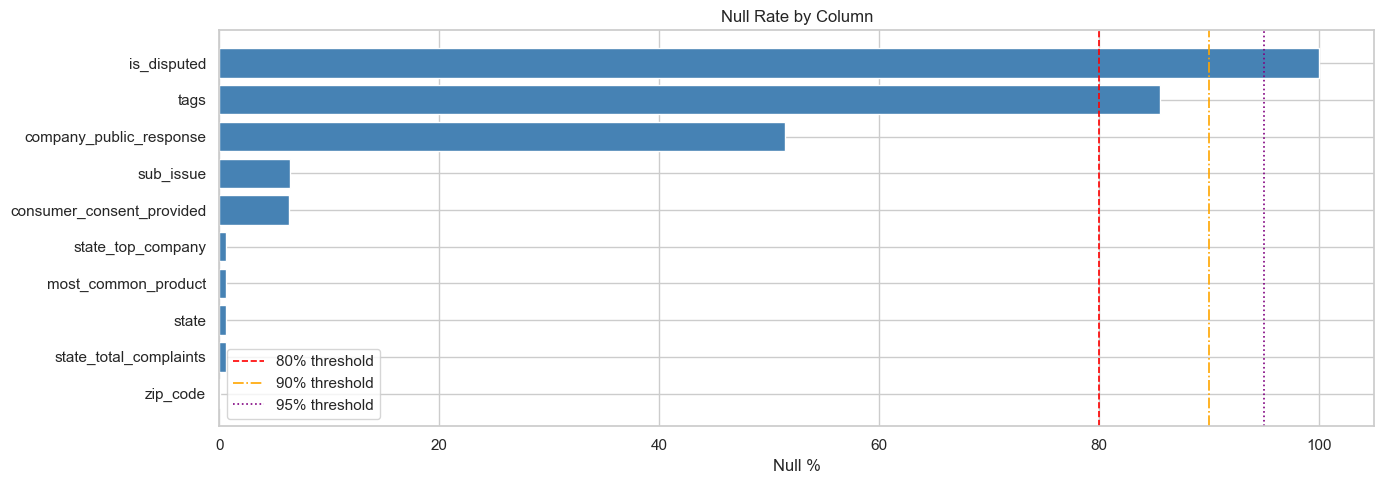

In [ ]:
null_analysis(df)

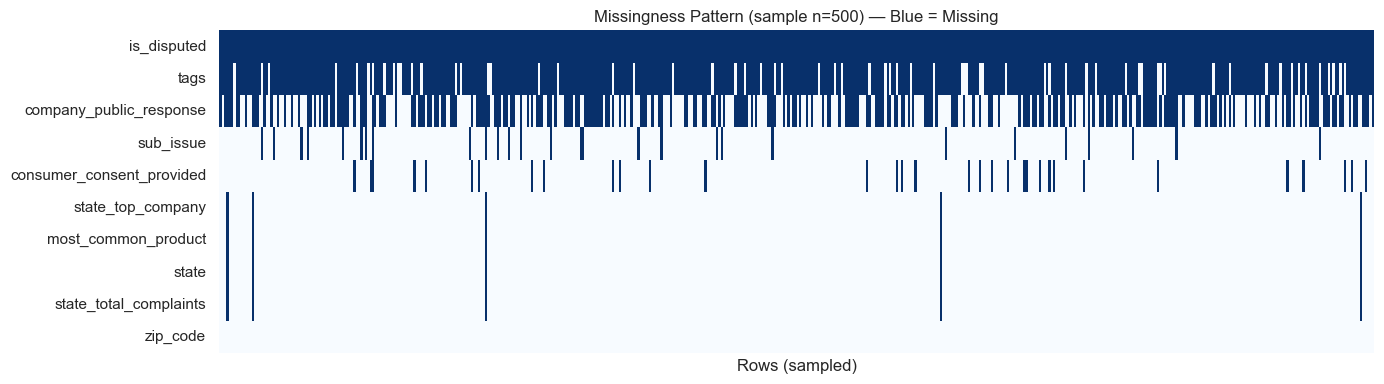

In [ ]:
# Missingness pattern heatmap (sample for performance)
cols_any_null = null_df[null_df["null_pct"] > 0].index.tolist()

if cols_any_null:
    sample_size = min(500, len(df))
    sample_df = df[cols_any_null].sample(sample_size, random_state=42)
    miss_matrix = sample_df.isnull().astype(int)

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        miss_matrix.T,
        cmap="Blues",
        cbar=False,
        yticklabels=True,
        xticklabels=False,
        ax=ax,
    )
    ax.set_title(f"Missingness Pattern (sample n={sample_size}) — Blue = Missing")
    ax.set_xlabel("Rows (sampled)")
    plt.tight_layout()
    plt.show()
else:
    print("No nulls found — missingness heatmap skipped")

##### Null Value Analysis — Insights

##### Drop Entirely
- **`is_disputed`** (100% null) — completely empty, confirmed useless. Drop from master table 
  and exclude from all analysis.
- **`tags`** (85.5% null) — too sparse to be reliable. Only ~60K of 415K rows have a value.
  Drop unless specifically analyzing Servicemember or Older American segments, in which case 
  treat as a sparse flag rather than a groupby column.

##### Use with Caution
- **`company_public_response`** (51.4% null) — majority missing. Do not use as a primary 
  groupby. Can be used as a binary flag (has public response vs. not) rather than its 
  actual value.
- **`sub_issue`** (6.5% null) — minor missingness, acceptable for drill-down analysis but 
  always pair with `issue` as the parent level.
- **`consumer_consent_provided`** (6.3% null) — small gap, safe to use as a filter for 
  narrative analysis but note the missing slice.

##### Structural Nulls — Investigate Join
- **`state`, `state_total_complaints`, `state_top_company`, `most_common_product`** 
  (all exactly 0.64% null, ~2,670 rows) — identical null counts suggest these come from 
  the same failed join. Likely complaints with missing or invalid state codes that 
  did not match `dim_states`. Flag these rows but do not drop the columns.
- **`zip_code`** (0.01% null) — negligible, safe to ignore.

##### Clean — No Action Needed
The following columns have zero or near-zero nulls and are safe to use as-is:

- Identifiers: `complaint_id`
- Dates: `date_received`, `date_sent_to_company`, `complaint_month_date`
- Core categoricals: `product`, `sub_product`, `issue`, `company`, `submitted_via`, 
  `company_response`
- Numerics: `days_to_response`, `company_total_complaints`, `company_avg_days_to_response`,
  `company_pct_timely`, `product_total_complaints`, `response_type_total`, 
  `response_type_avg_days`
- Flags: `is_timely_response`, `has_narrative`
- Text: `complaint_what_happened`

##### Summary Recommendation
| Action | Columns |
|---|---|
| Drop | `is_disputed`, `tags` |
| Use as binary flag only | `company_public_response` |
| Use with awareness | `sub_issue`, `consumer_consent_provided` |
| Investigate join gap | `state`, `state_total_complaints`, `state_top_company`, `most_common_product` |
| Safe to use | Everything else |

##### 3.1.3 Categorize null types

##### Null Classification — All Columns with Any Nulls

| Column | Null Count | Null % | Null Type | Explanation |
|---|---|---|---|---|
| `is_disputed` | 415,257 | 100.00% | Unknown | Dispute tracking appears to have stopped; no data available across entire dataset |
| `tags` | 355,213 | 85.54% | Not applicable | Only populated for special cohorts (Servicemember, Older American); majority of complaints have no tag by design |
| `company_public_response` | 213,594 | 51.44% | Unavailable | Company may choose not to provide a public response; opt-in field |
| `sub_issue` | 26,807 | 6.46% | Not applicable | Not every issue has a sub-issue; parent `issue` field is always populated |
| `consumer_consent_provided` | 26,126 | 6.29% | Unavailable | Consumer may not have consented to share details; expected gap |
| `state_top_company` | 2,670 | 0.64% | Missing join | Complaint has no valid state match in `dim_states`; structural join gap |
| `most_common_product` | 2,670 | 0.64% | Missing join | Same join gap as `state_top_company`; state-level dim lookup failed |
| `state` | 2,670 | 0.64% | Unknown | State code missing, invalid, or not collected at submission |
| `state_total_complaints` | 2,670 | 0.64% | Missing join | Downstream of missing `state`; propagated null from failed join |
| `zip_code` | 27 | 0.01% | Unknown | May not have been collected or entered at submission |
| `company_response` | 1 | 0.00% | Unknown | Single record; likely a data entry or pipeline error |
| `response_type_total` | 1 | 0.00% | Missing join | Same record as `company_response` null; join to `dim_response_types` failed |
| `response_type_avg_days` | 1 | 0.00% | Missing join | Same record propagation as above |
| `most_common_issue` | 3 | 0.00% | Missing join | Negligible; likely edge case in `dim_products` join |
| `issue` | 6 | 0.00% | Unknown | Negligible; likely malformed records at source |
| `sub_product` | 6 | 0.00% | Not applicable | Not every product has a sub-product |

##### Null Type Definitions

| Null Type | Meaning | Recommended Handling |
|---|---|---|
| Not applicable | Null is valid by design; field does not apply to all rows | Keep as-is; do not impute |
| Unavailable | Field exists but value was not provided by the consumer or company | Keep as-is or create a binary has/has-not flag |
| Missing join | Null introduced during table merging; source row had no matching key | Investigate upstream; safe to keep but flag the affected rows |
| Unknown | Unclear whether null is structural, collection gap, or data error | Treat conservatively; exclude from analysis or flag separately |

### 3.2 Outlier analysis

In [ ]:
def outlier_analysis(df, numeric_cols):
    outlier_summary = []
    for col in numeric_cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        z = np.abs(stats.zscore(s))
        n_z = (z > 3).sum()
        outlier_summary.append(
            {
                "column": col,
                "mean": s.mean(),
                "median": s.median(),
                "std": s.std(),
                "min": s.min(),
                "max": s.max(),
                "IQR_low": lo,
                "IQR_high": hi,
                "n_IQR_outliers": n_out,
                "pct_IQR_outliers": round(n_out / len(s) * 100, 2),
                "n_zscore>3": n_z,
            }
        )

    outlier_df = pd.DataFrame(outlier_summary)
    print("=== Outlier Summary ===")
    return outlier_df

In [ ]:
outlier_analysis(df, numeric_cols)

=== Outlier Summary ===


,column,mean,median,std,min,max,IQR_low,IQR_high,n_IQR_outliers,pct_IQR_outliers,n_zscore>3
0,days_to_response,1.065925,0.00,5.632995,0.0,408.00,0.000,0.000,41097,9.90,8623
1,company_total_complaints,46946.062901,51114.00,23665.975696,1.0,75862.00,-39814.500,124373.500,0,0.00,0
2,company_avg_days_to_response,1.065480,0.91,0.529853,0.0,61.00,-0.055,2.225,6877,1.66,4052
3,company_pct_timely,99.753125,100.00,0.797114,0.0,100.00,99.975,100.015,87688,21.12,1355
4,product_total_complaints,63827.583776,87347.00,39398.079872,1.0,120474.00,-98307.500,198952.500,0,0.00,0
5,state_total_complaints,26118.043908,17866.00,20145.353645,1.0,61156.00,-45902.000,100466.000,0,0.00,0
6,response_type_total,239779.461905,306974.00,113338.208561,27.0,306974.00,-314031.000,679577.000,0,0.00,0
7,response_type_avg_days,1.069180,1.08,0.066201,0.9,4.22,1.080,1.080,108279,26.08,27


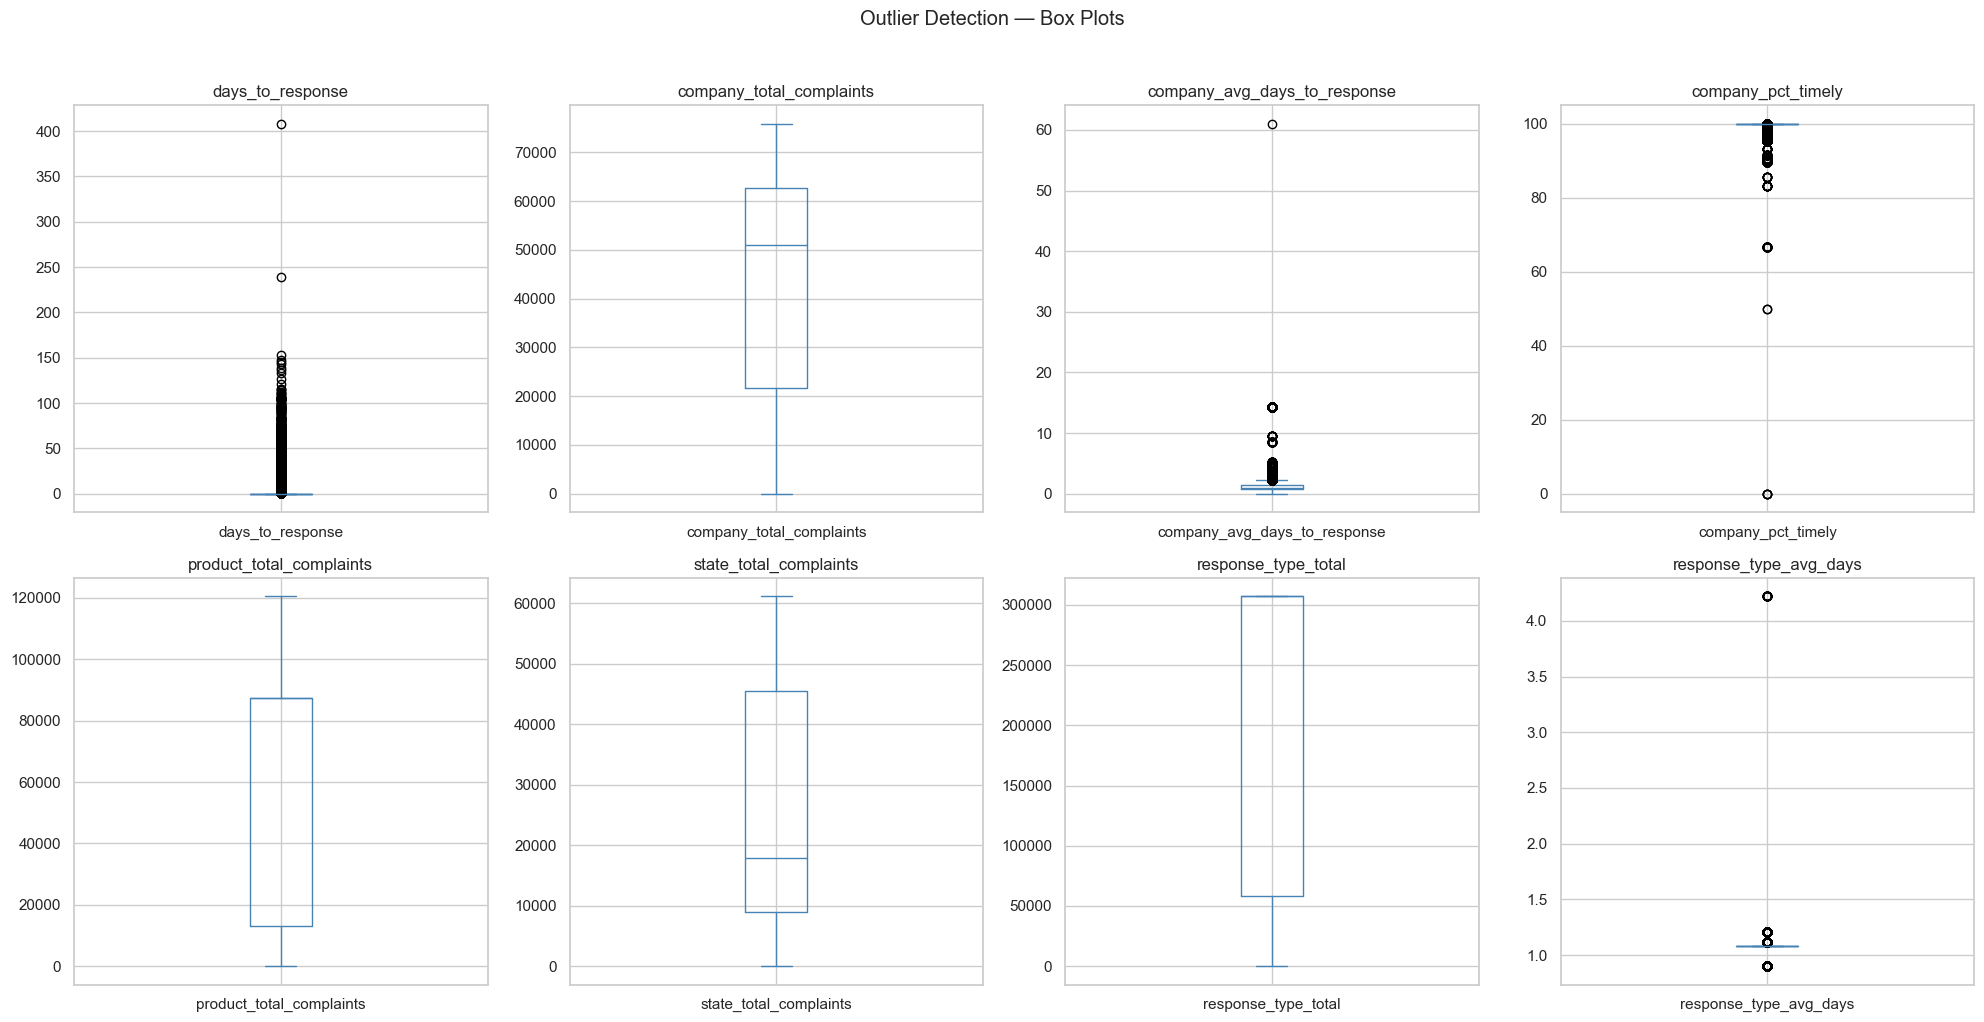

In [ ]:
if numeric_cols:
    n_cols = 4
    n_rows = math.ceil(len(numeric_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, numeric_cols):
        df[col].dropna().plot.box(ax=ax, color="steelblue")
        ax.set_title(col)

    # Hide any unused subplots
    for ax in axes[len(numeric_cols) :]:
        ax.set_visible(False)

    plt.suptitle("Outlier Detection — Box Plots", y=1.02)
    plt.tight_layout()
    plt.show()

##### Outlier Analysis — Box Plots

* `days_to_response` Most complaints are resolved within 0–2 days (median near 0), but extreme outliers reach up to 420 days. The distribution is heavily right-skewed. Cap or log-transform before using in any model.

* `company_total_complaints` Wide IQR (~20K–62K) reflecting genuine size differences between companies. The top outlier (~75K) is likely Capital One or Chase. Not a data error — reflects market concentration. Use as-is for ranking; normalize if comparing rates.

* `company_avg_days_to_response` Median near 0 with a single high outlier (~62 days). That outlier company is a clear underperformer worth flagging separately. Consider Winsorizing at 95th percentile.

* `company_pct_timely` Heavily left-skewed — most companies cluster near 100%, with a few outliers dropping to ~30–60%. The low outliers represent companies with compliance issues and are analytically meaningful, not errors. Keep as-is.

* `product_total_complaints` Wide spread (IQR ~15K–85K) driven by the dominance of a few products (Checking/savings, Credit cards). No true outliers — reflects natural product volume differences. Use for ranking only.

* `state_total_complaints` Similar pattern to product — large states (CA, FL, TX) naturally dominate. IQR is wide but no anomalies. Population-driven variance, not a data error.

* `response_type_total` Extremely wide IQR reflecting the dominance of "Closed with explanation" (~307K) vs. all other response types. Expected given only 5 categories exist. Not meaningful to outlier-treat.

* `response_type_avg_days` Tight distribution (1.0–1.5 days) with one outlier at ~4.1 days. Low variance overall — one response type is notably slower. Worth identifying which type that is for operational insight.

##### Summary

| Column | Has Outliers | Nature | Action |
|---|---|---|---|
| `days_to_response` | Yes | Data quality / edge cases | Cap or log-transform |
| `company_total_complaints` | No | Natural size variance | Use as-is |
| `company_avg_days_to_response` | Yes | Underperforming company | Flag, consider Winsorize |
| `company_pct_timely` | Yes | Meaningful compliance gap | Keep, flag low outliers |
| `product_total_complaints` | No | Natural volume variance | Use as-is |
| `state_total_complaints` | No | Population-driven | Use as-is |
| `response_type_total` | No | Category dominance | Use as-is |
| `response_type_avg_days` | Yes | One slow response type | Investigate which type |

# 4 EDA

### 4.1 Univariate EDA 

##### 4.1.1 Binary variable EDA

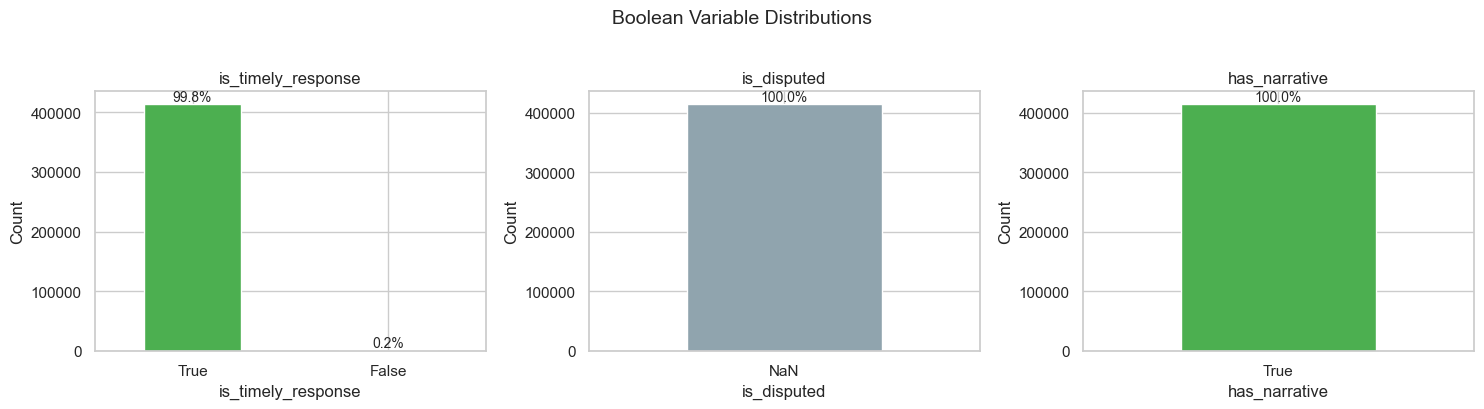

In [ ]:
n = len(bool_cols)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, bool_cols):
    vc = (
        df[col]
        .value_counts(dropna=False)
        .rename(index={True: "True", False: "False", pd.NA: "NaN", None: "NaN"})
    )
    colors = [
        "#4CAF50" if str(i) == "True" else "#EF5350" if str(i) == "False" else "#90A4AE"
        for i in vc.index
    ]
    vc.plot.bar(ax=ax, color=colors, edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.set_xticklabels(vc.index, rotation=0)
    total = vc.sum()
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height()/total:.1%}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.suptitle("Boolean Variable Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

As is_dispute, is_timely_response and has_narrative both have about 100% of single vlaue, then it doesn't have distinguish power, we are then safe to drop them

##### 4.1.2 Categorical variable EDA

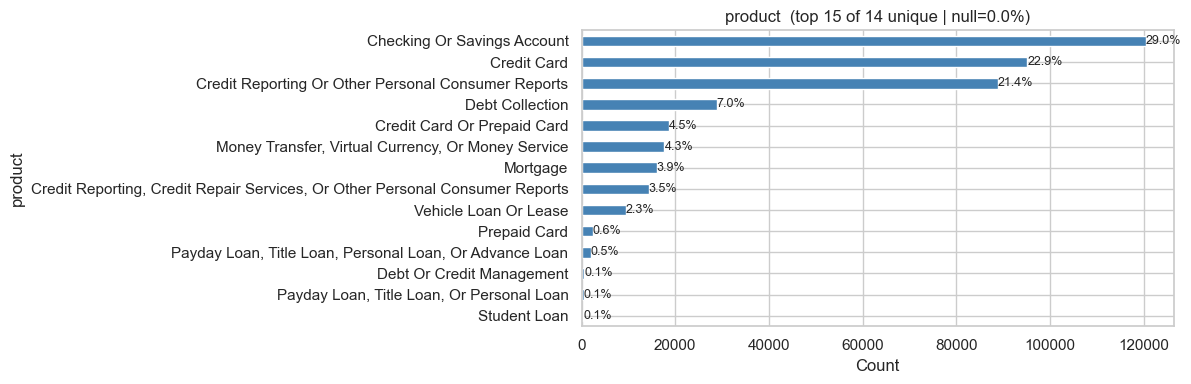

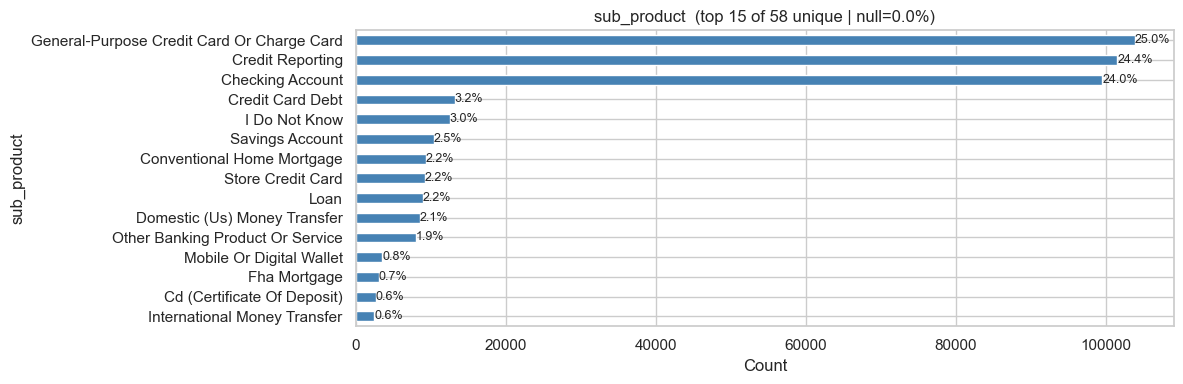

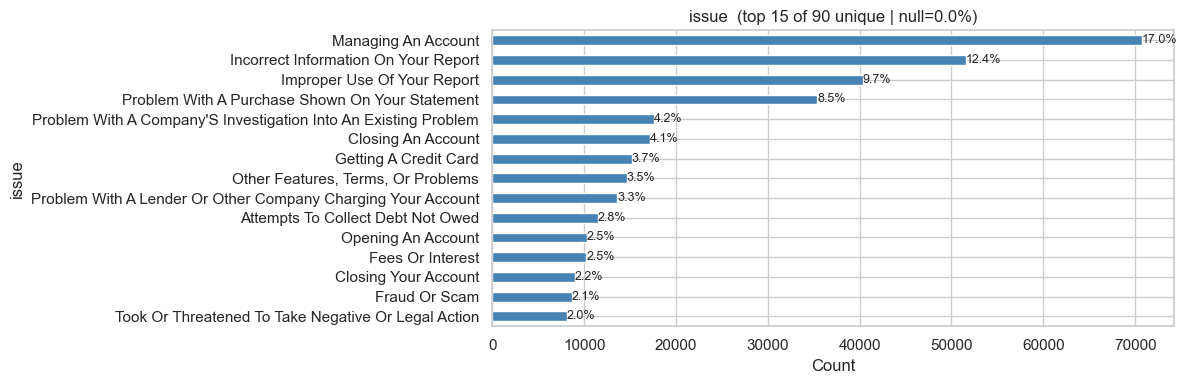

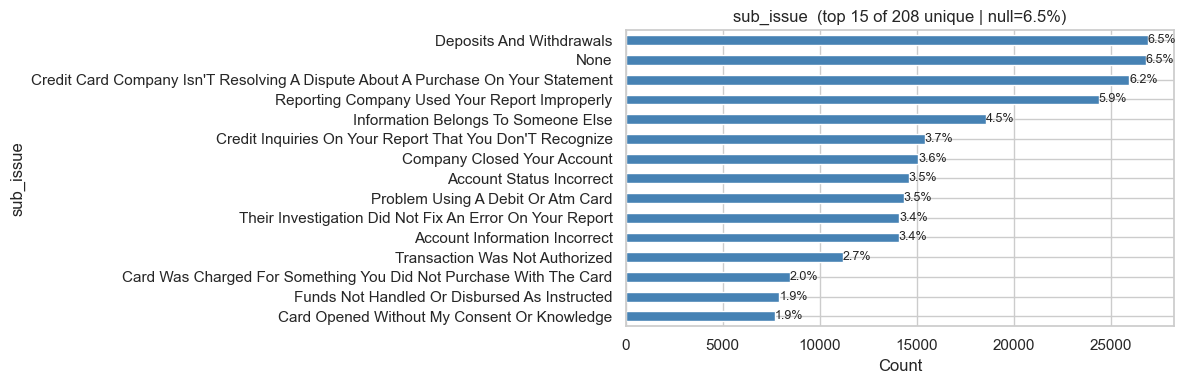

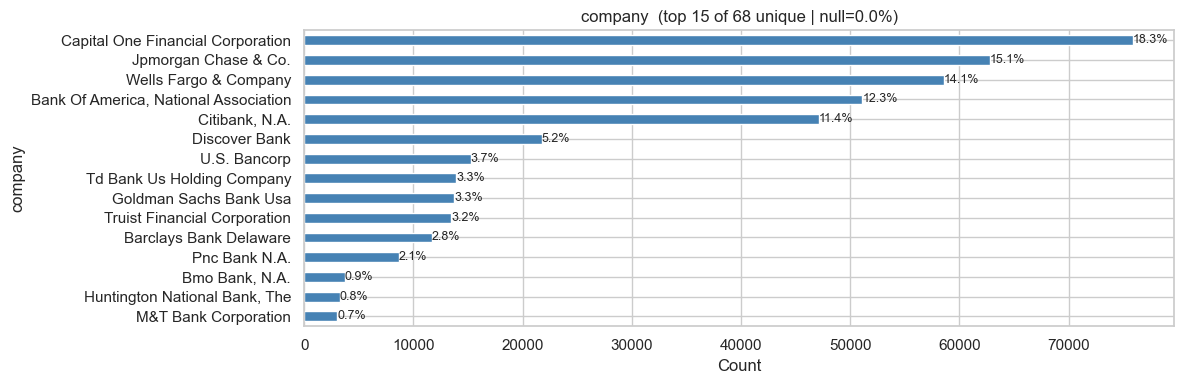

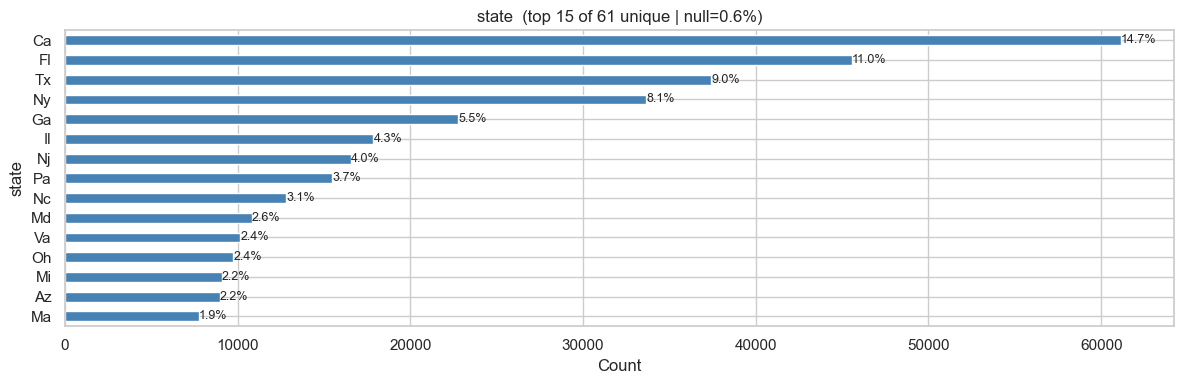

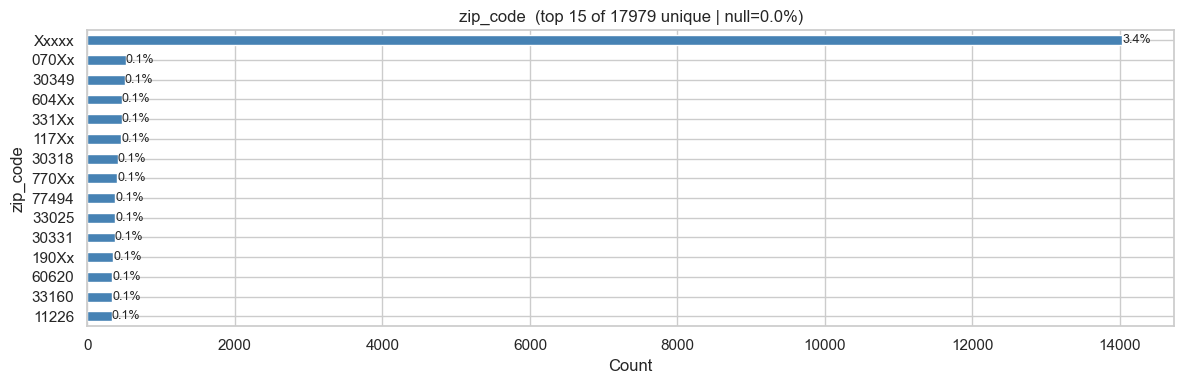

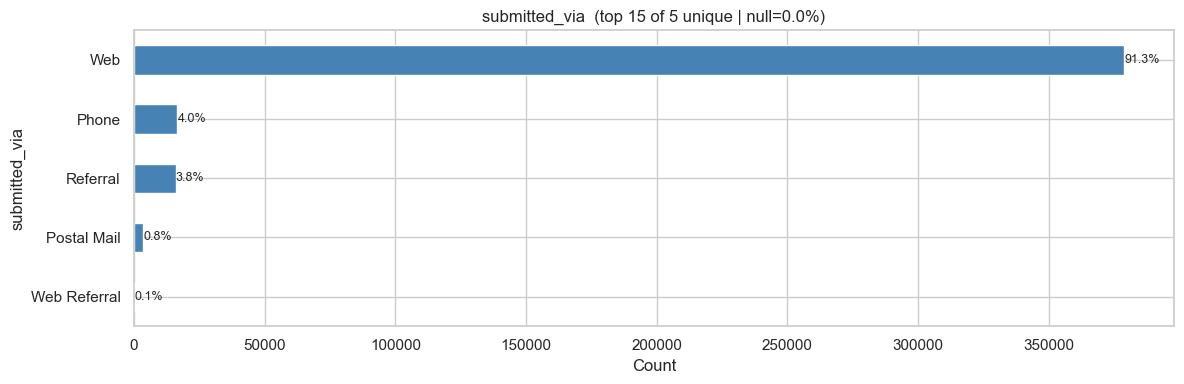

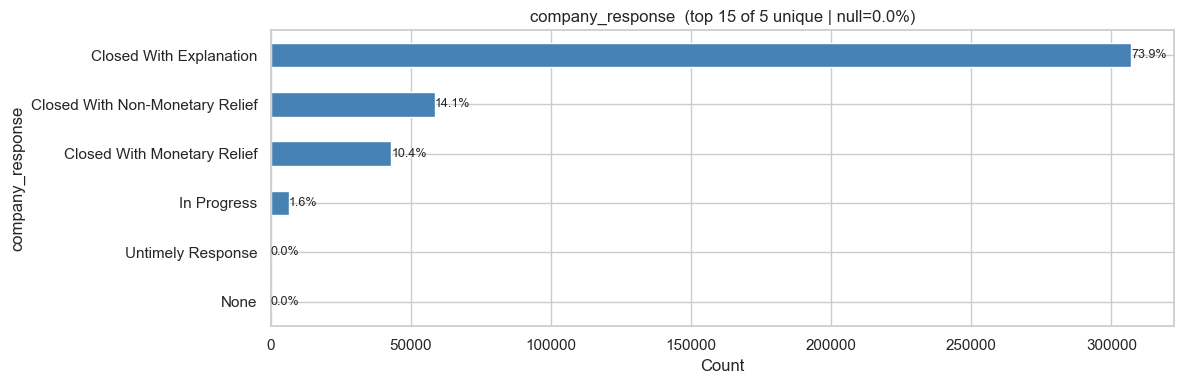

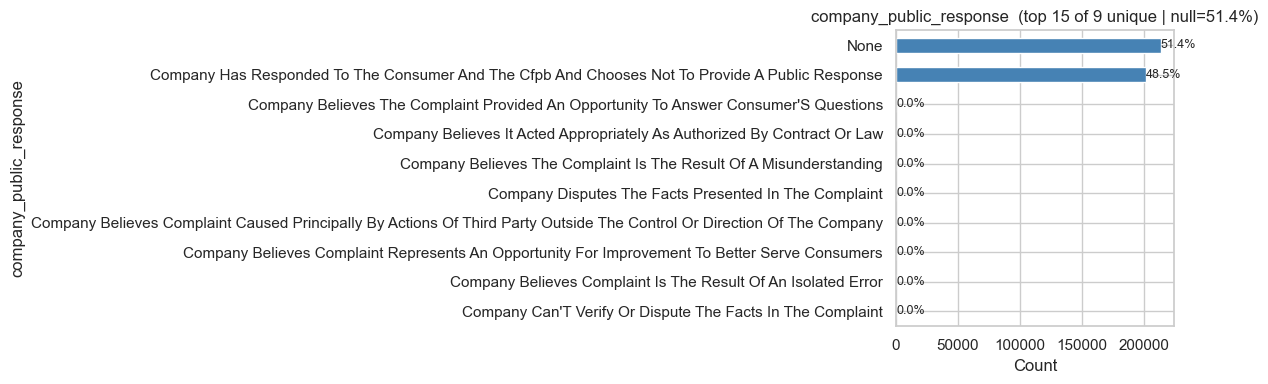

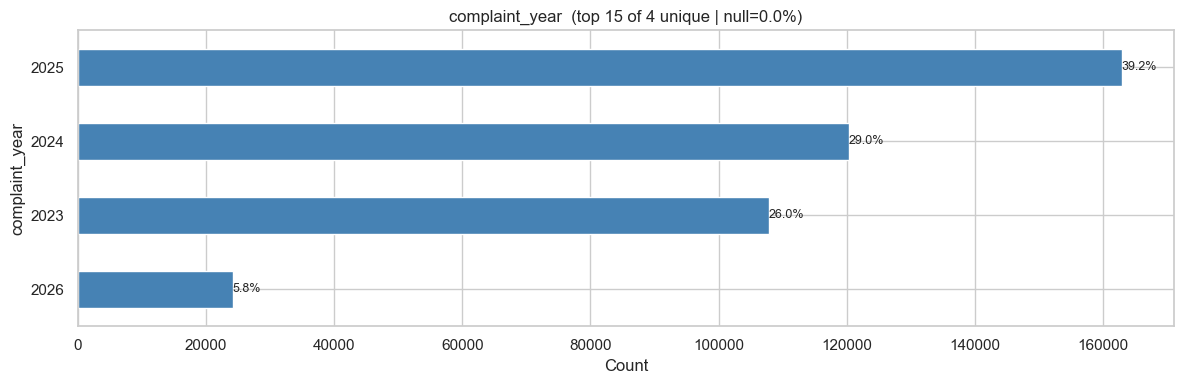

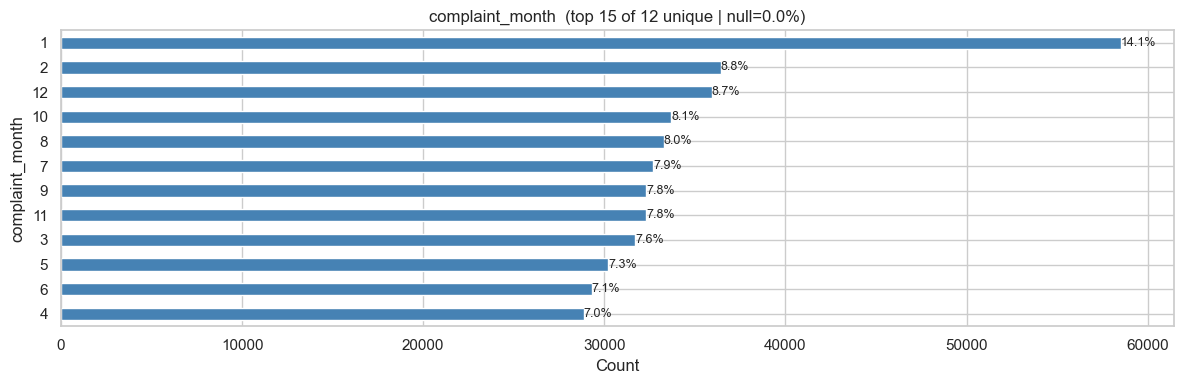

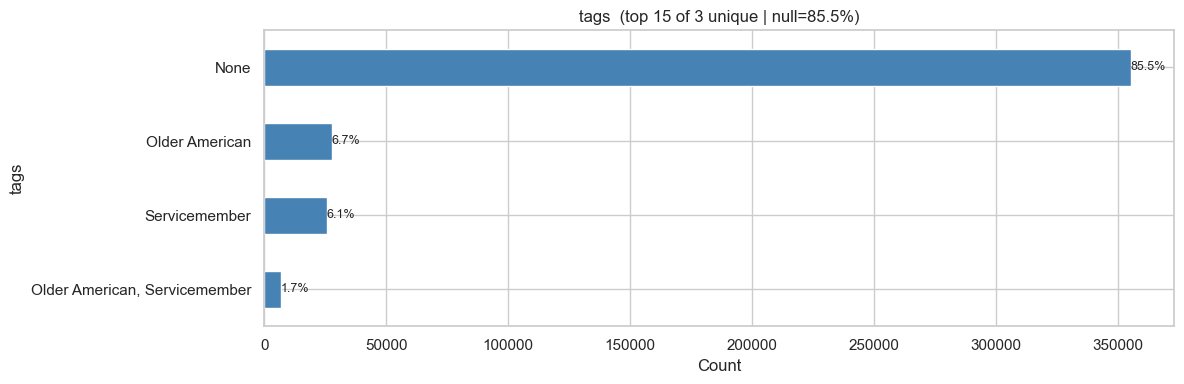

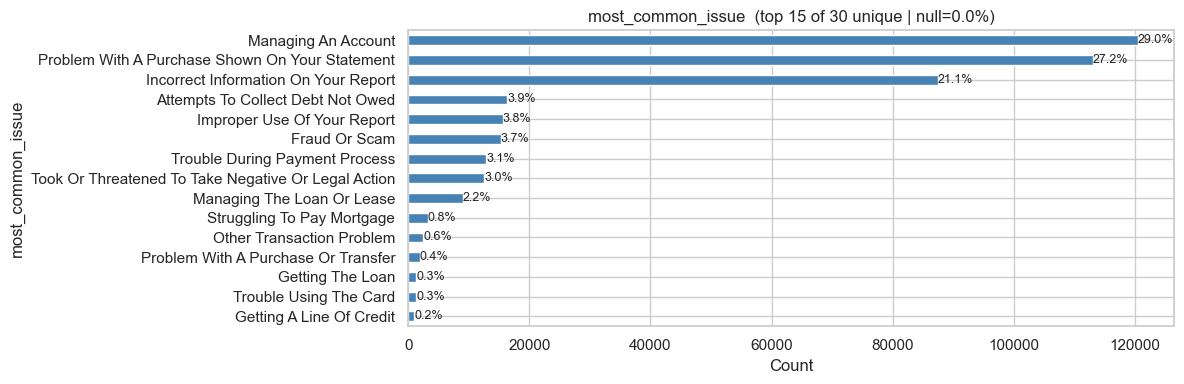

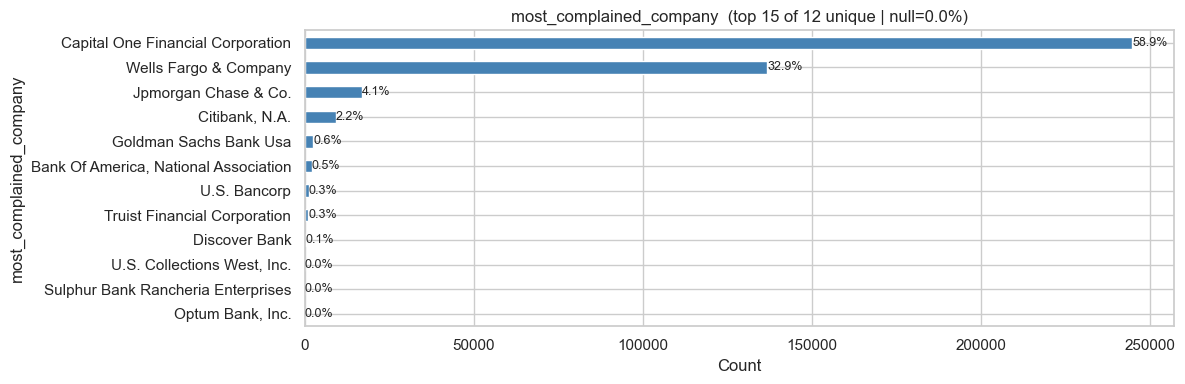

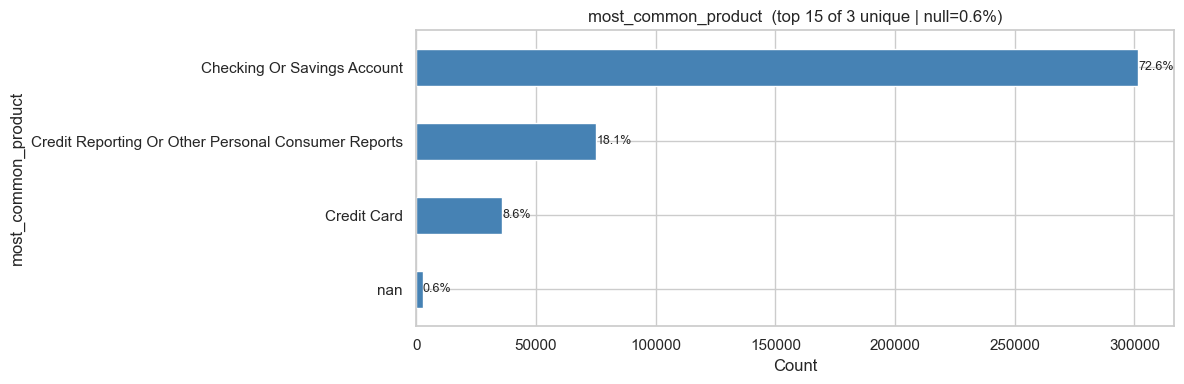

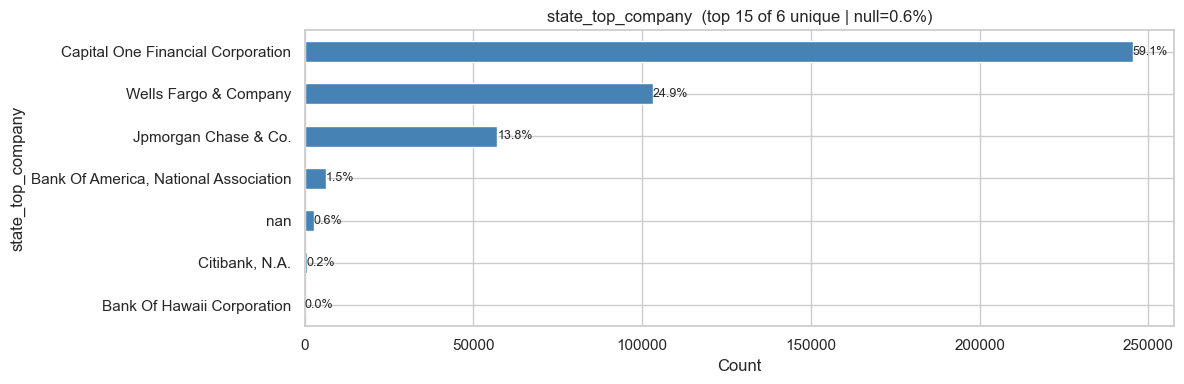

In [ ]:
TOP_N = 15

for col in categorical_cols:
    vc = df[col].value_counts(dropna=False).head(TOP_N)
    fig, ax = plt.subplots(figsize=(12, 4))
    vc.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(
        f"{col}  (top {TOP_N} of {df[col].nunique()} unique | null={df[col].isnull().mean():.1%})"
    )
    ax.set_xlabel("Count")
    total = len(df)
    for p in ax.patches:
        ax.annotate(
            f"{p.get_width()/total:.1%}",
            (p.get_width(), p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()

##### Categorical Variable Distribution

##### Volume is driven by a small number of dominant categories across almost every dimension.

* `Products` & `Issues`: The top 3 products (Checking/Savings, Credit Card, Credit Reporting) account for 73% of 
all complaints. This concentration carries through to sub-product and issue level — 
Managing an Account and Incorrect Information on Report alone cover ~30% of all issues. 
For any segmentation analysis, treat these top categories as primary and group the rest.

* `Companies` & `Geography`: 5 companies (Capital One, JPMorgan Chase, Wells Fargo, BofA, Citibank) generate 71% of 
complaints. Geographically, CA, FL, TX, and NY represent 43% of volume — broadly 
proportional to population. Normalize by population before drawing geographic conclusions.

* `Channels` & `Responses`: Web is the submission channel for 91% of complaints — low variance, limited standalone 
value. On the response side, 74% are closed with explanation; monetary and non-monetary relief together cover ~25%. 

* `company_public_response` is effectively empty — convert to a binary flag.

* `Temporal`: Complaint volume is growing: 2023 (26%) → 2024 (29%) → 2025 (39%). No strong seasonal 
signal at the month level. Exclude 2026 or normalize when doing YoY comparisons.

* Columns to Treat as Labels, Not Dimensions**: `most_common_issue`, `most_complained_company`, `most_common_product`, and `state_top_company` are joined dim-level annotations. Use for labeling only — do not aggregate or groupby on these.

##### 4.1.3 Numeric variable distribution EDA

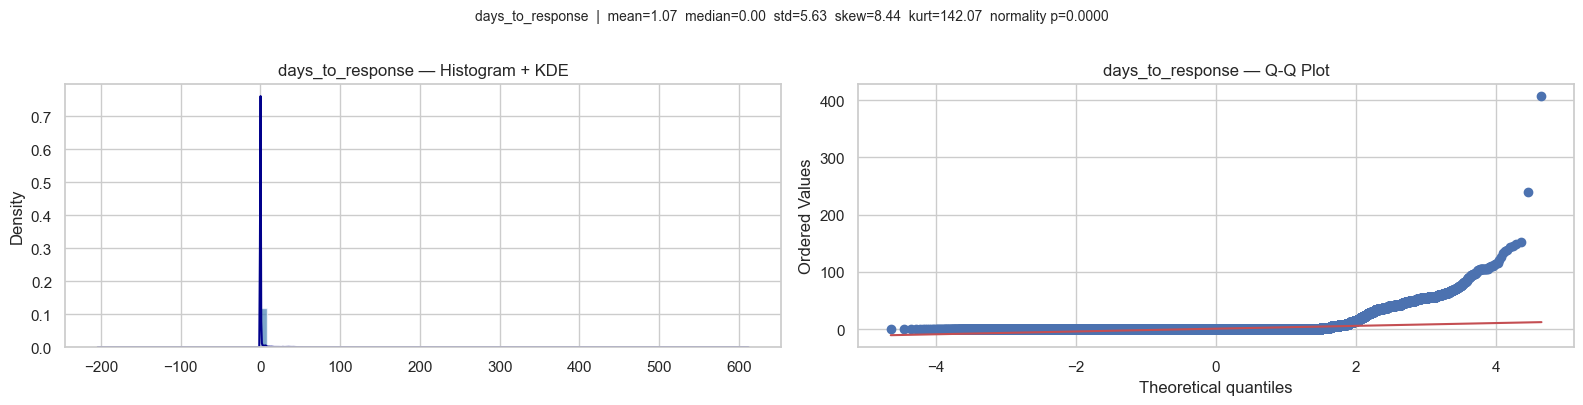

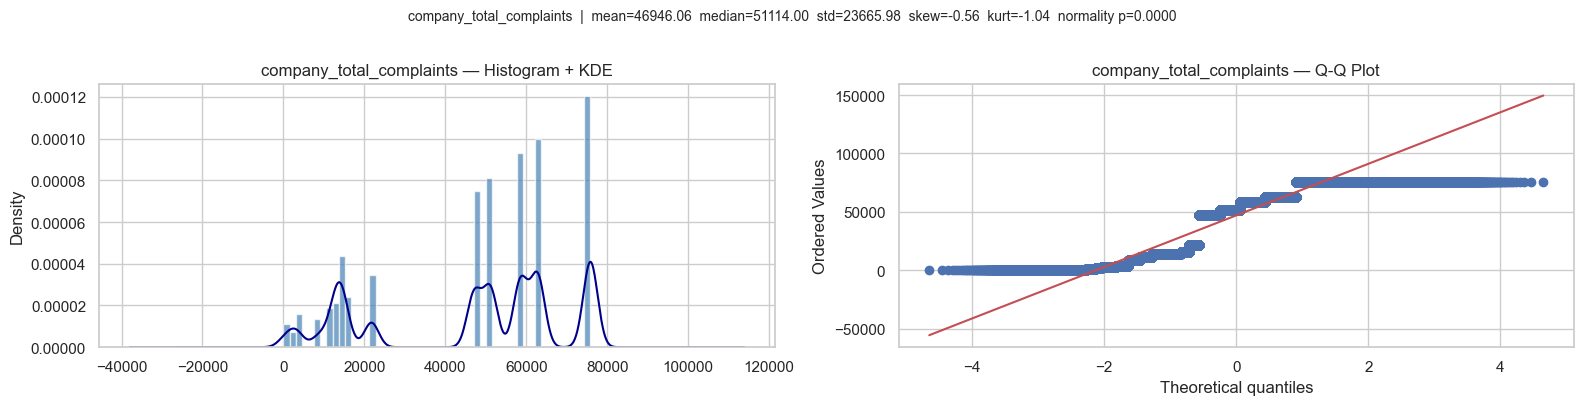

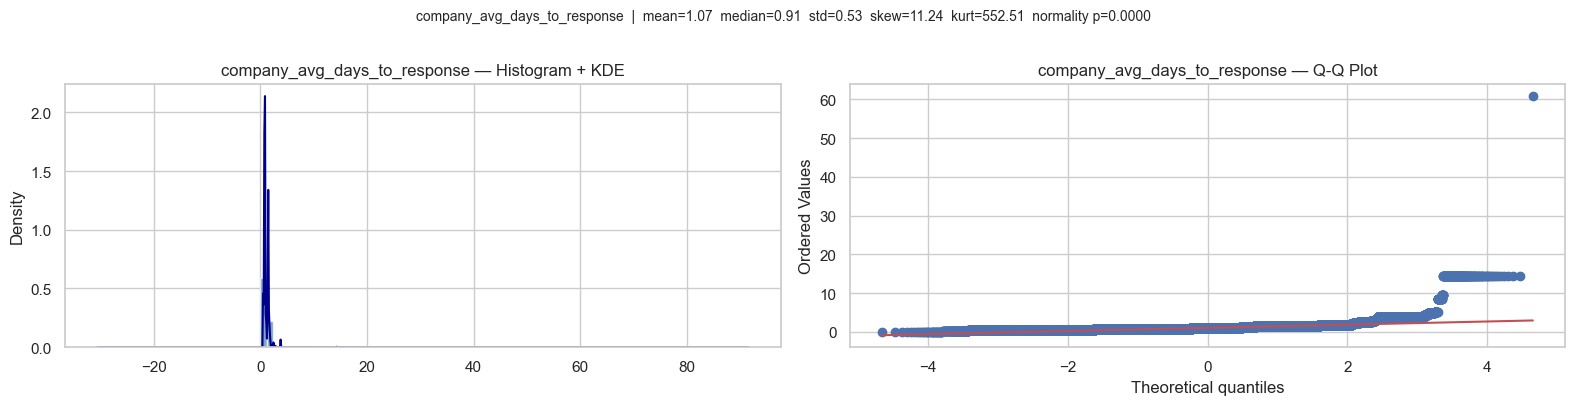

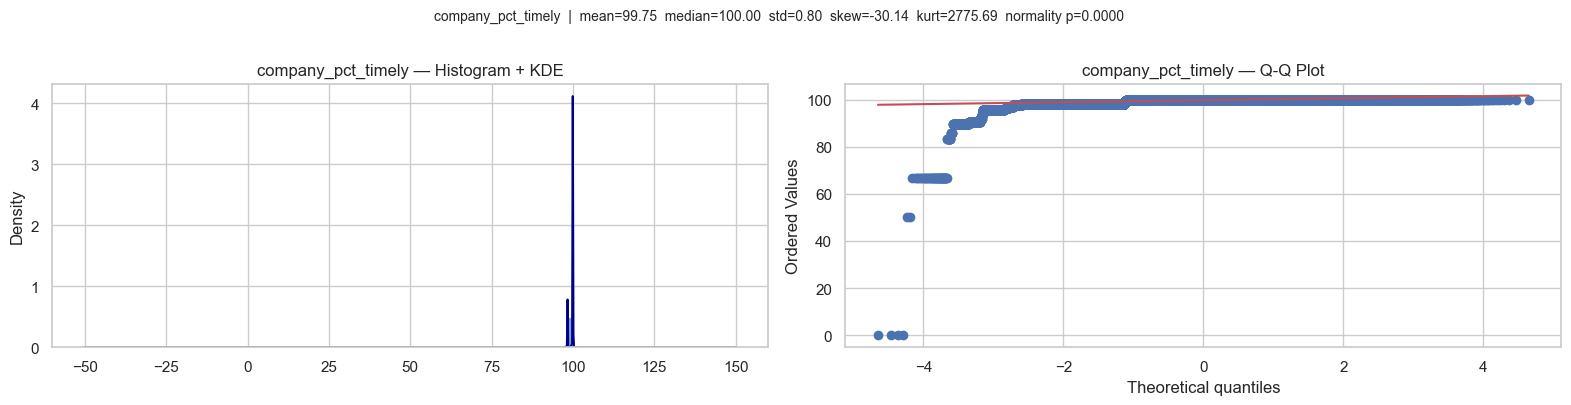

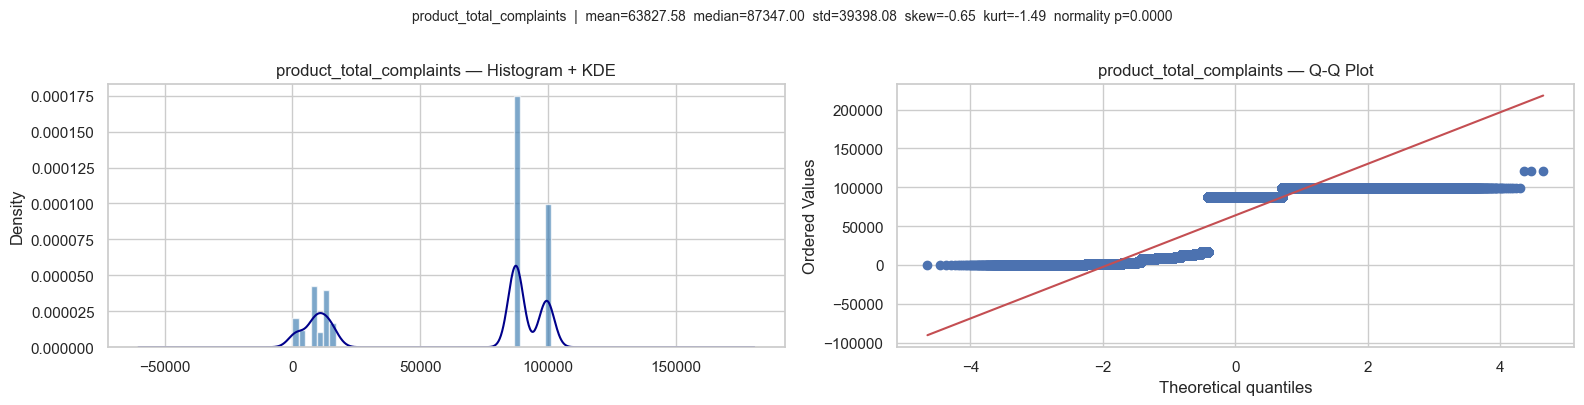

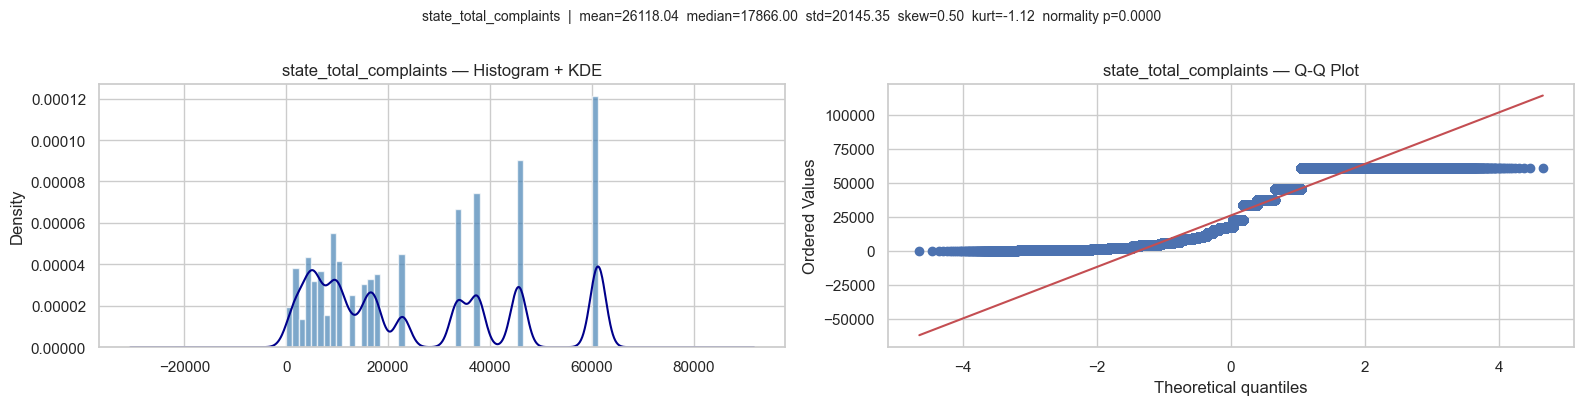

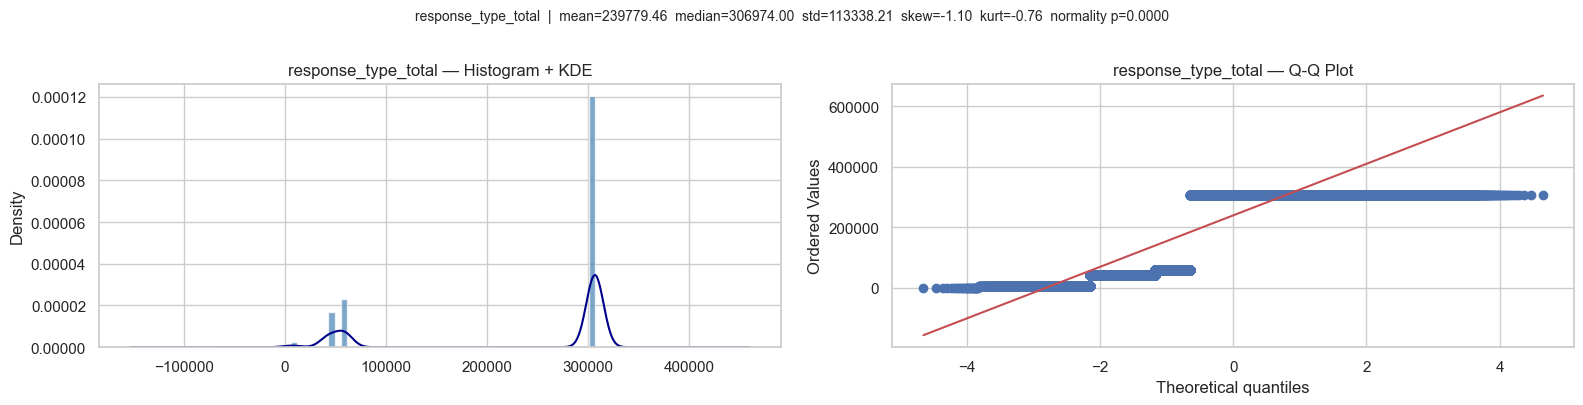

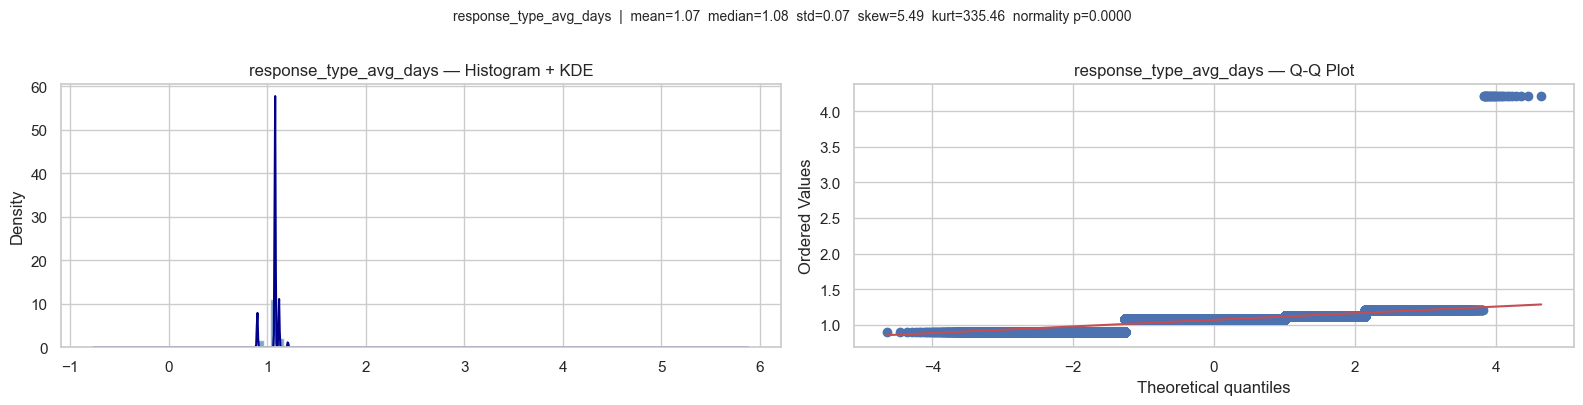

In [ ]:
for col in numeric_cols:
    s = df[col].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Histogram + KDE
    s.plot.hist(
        bins=50,
        ax=axes[0],
        color="steelblue",
        edgecolor="white",
        density=True,
        alpha=0.7,
    )
    s.plot.kde(ax=axes[0], color="darkblue")
    axes[0].set_title(f"{col} — Histogram + KDE")

    # Q-Q plot
    stats.probplot(s, dist="norm", plot=axes[1])
    axes[1].set_title(f"{col} — Q-Q Plot")

    # Stats annotation
    skew = s.skew()
    kurt = s.kurt()
    _, p_norm = stats.normaltest(s.sample(min(5000, len(s)), random_state=42))
    fig.suptitle(
        f"{col}  |  mean={s.mean():.2f}  median={s.median():.2f}  "
        f"std={s.std():.2f}  skew={skew:.2f}  kurt={kurt:.2f}  "
        f"normality p={p_norm:.4f}",
        fontsize=10,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

## Numerical Variable Distribution

* `days_to_response` Most complaints are resolved within 0–2 days (median near 0), but extreme outliers reach up to 420 days. The distribution is heavily right-skewed. Cap or log-transform before using in any model.

* `company_total_complaints` Wide IQR (~20K–62K) reflecting genuine size differences between companies. The top outlier (~75K) is likely Capital One or Chase. Not a data error — reflects market concentration. Use as-is for ranking; normalize if comparing rates.

* `company_avg_days_to_response` Median near 0 with a single high outlier (~62 days). That outlier company is a clear underperformer worth flagging separately. Consider Winsorizing at 95th percentile.

* `company_pct_timely` Heavily left-skewed — most companies cluster near 100%, with a few outliers dropping to ~30–60%. The low outliers represent companies with compliance issues and are analytically meaningful, not errors. Keep as-is.

* `product_total_complaints` Wide spread (IQR ~15K–85K) driven by the dominance of a few products (Checking/savings, Credit cards). No true outliers — reflects natural product volume differences. Use for ranking only.

* `state_total_complaints` Similar pattern to product — large states (CA, FL, TX) naturally dominate. IQR is wide but no anomalies. Population-driven variance, not a data error.

* `response_type_total` Extremely wide IQR reflecting the dominance of "Closed with explanation" (~307K) vs. all other response types. Expected given only 5 categories exist. Not meaningful to outlier-treat.

* `response_type_avg_days` Tight distribution (1.0–1.5 days) with one outlier at ~4.1 days. Low variance overall — one response type is notably slower. Worth identifying which type that is for operational insight.

### 4.2 Bi-variate EDA 

##### 4.2.1 Numeric bi-variate 

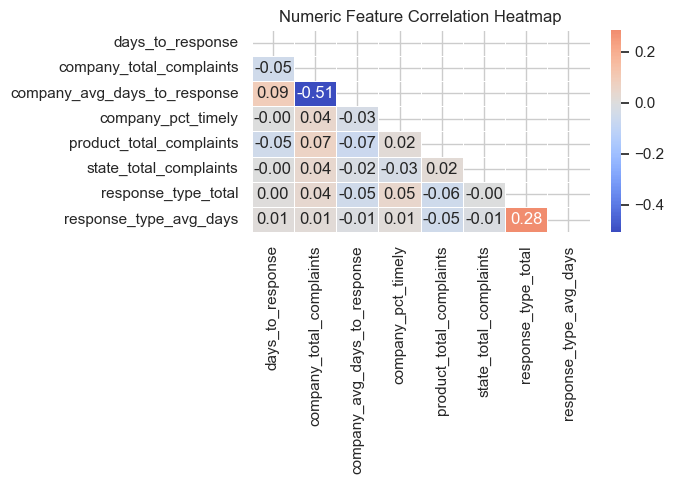

In [ ]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        linewidths=0.5,
    )
    ax.set_title("Numeric Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥2 numeric columns for correlation heatmap")

##### Numeric Feature Correlation

* Overall, numeric features in this dataset are largely independent of one another. (|r| < 0.10)

* The only two correlations worth noting are
    - **`company_total_complaints` — `company_avg_days_to_response` (-0.51)**: Larger companies tend to respond faster —  likely because high-volume companies have more mature complaint handling operations. This is a structural relationship, not a causal one. Avoid using both as independent features in the same model.

    - **`response_type_total` — `response_type_avg_days` (0.28)**: Higher-volume response types take slightly longer on average. Weak but directionally sensible — busier resolution categories carry more processing load.

##### 4.2.2 Categorical bi-variate 

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

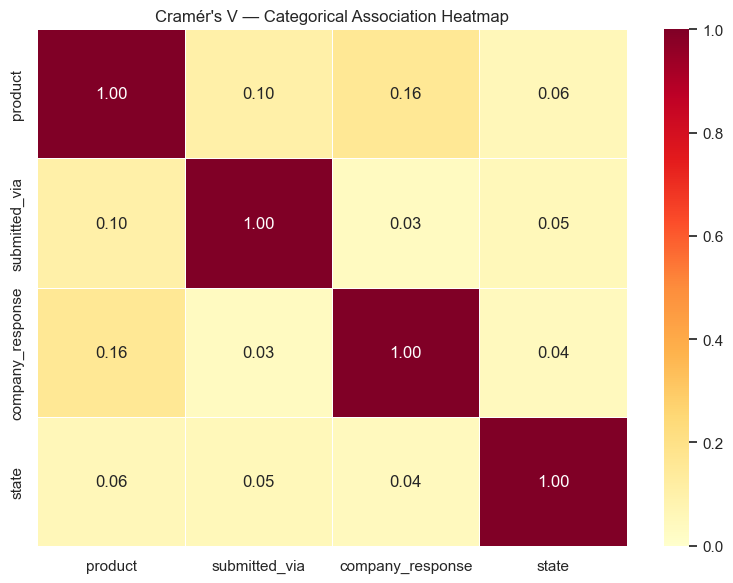

In [ ]:
cat_subset = ["product", "submitted_via", "company_response", "state"]
cat_subset = [c for c in cat_subset if c in df.columns]

if len(cat_subset) > 1:
    cv_matrix = pd.DataFrame(index=cat_subset, columns=cat_subset, dtype=float)
    for c1 in cat_subset:
        for c2 in cat_subset:
            if c1 == c2:
                cv_matrix.loc[c1, c2] = 1.0
            else:
                tmp = df[[c1, c2]].dropna()
                cv_matrix.loc[c1, c2] = (
                    cramers_v(tmp[c1], tmp[c2]) if len(tmp) > 10 else np.nan
                )

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cv_matrix.astype(float),
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=1,
    )
    ax.set_title("Cramér's V — Categorical Association Heatmap")
    plt.tight_layout()
    plt.show()

##### Categorical Feature Correlation

* Overall, categorical features in this dataset are largely independent of one another.  (r < 0.2)

#### 4.2.3 Bivariate with time 

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_3946/1507389022.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.set_index('date_received').resample('M').size().rename('n_complaints')


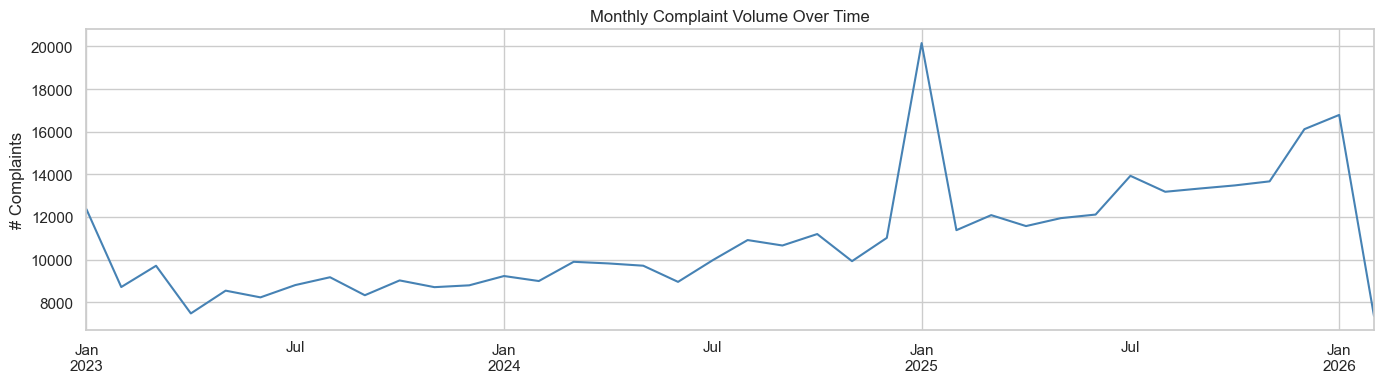

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_3946/1507389022.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq='M'), 'product'])


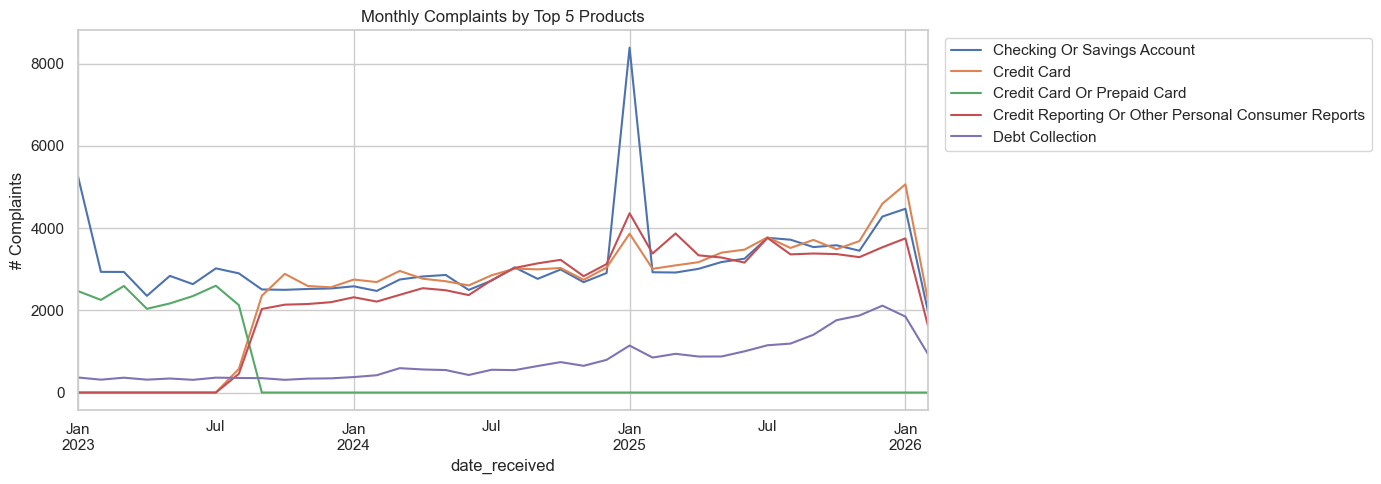

In [ ]:
if "date_received" in df.columns:
    ts = df.set_index("date_received").resample("M").size().rename("n_complaints")
    fig, ax = plt.subplots(figsize=(14, 4))
    ts.plot(ax=ax, color="steelblue")
    ax.set_title("Monthly Complaint Volume Over Time")
    ax.set_ylabel("# Complaints")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

    # Breakdown by top products over time
    if "product" in df.columns:
        top_products = df["product"].value_counts().head(5).index
        ts_prod = (
            df[df["product"].isin(top_products)]
            .set_index("date_received")
            .groupby([pd.Grouper(freq="M"), "product"])
            .size()
            .unstack("product", fill_value=0)
        )
        fig, ax = plt.subplots(figsize=(14, 5))
        ts_prod.plot(ax=ax)
        ax.set_title("Monthly Complaints by Top 5 Products")
        ax.set_ylabel("# Complaints")
        ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

##### Complaint volume has grown consistently since 2023, with one anomalous spike at the start of 2025.

* **Overall Trend** Monthly complaints grew from ~8K–12K in 2023 to a stable ~12K–16K range 
  through 2025. The Feb 2026 drop-off is a data truncation artifact, not a real decline.

* **January 2025 Spike (~20K)** A sharp isolated spike nearly doubling typical monthly volume, 
  driven almost entirely by Checking or Savings Account (~8K). Likely tied to a specific 
  external event — treat this month as an outlier in all trend analysis.

* **Product Shifts** Credit Card or Prepaid Card drops to near zero mid-2023 — likely a 
  reclassification, not a real decline. Credit Reporting and Credit Card are now converging 
  with Checking and Savings as top drivers entering 2026, signaling a compositional shift 
  worth monitoring.

* key takes aways
* put at the top or dir doc

In [ ]:
def breakdown_analysis(df, col, ax):
    top_product = df[col].value_counts().head(10)
    top_product.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.invert_yaxis()
    ax.set_title("Top 10 — Jan 2025")
    ax.set_xlabel("# Complaints")
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_width()):,}",
            (p.get_width(), p.get_y() + p.get_height() / 2),
            ha="left",
            va="center",
            fontsize=9,
        )

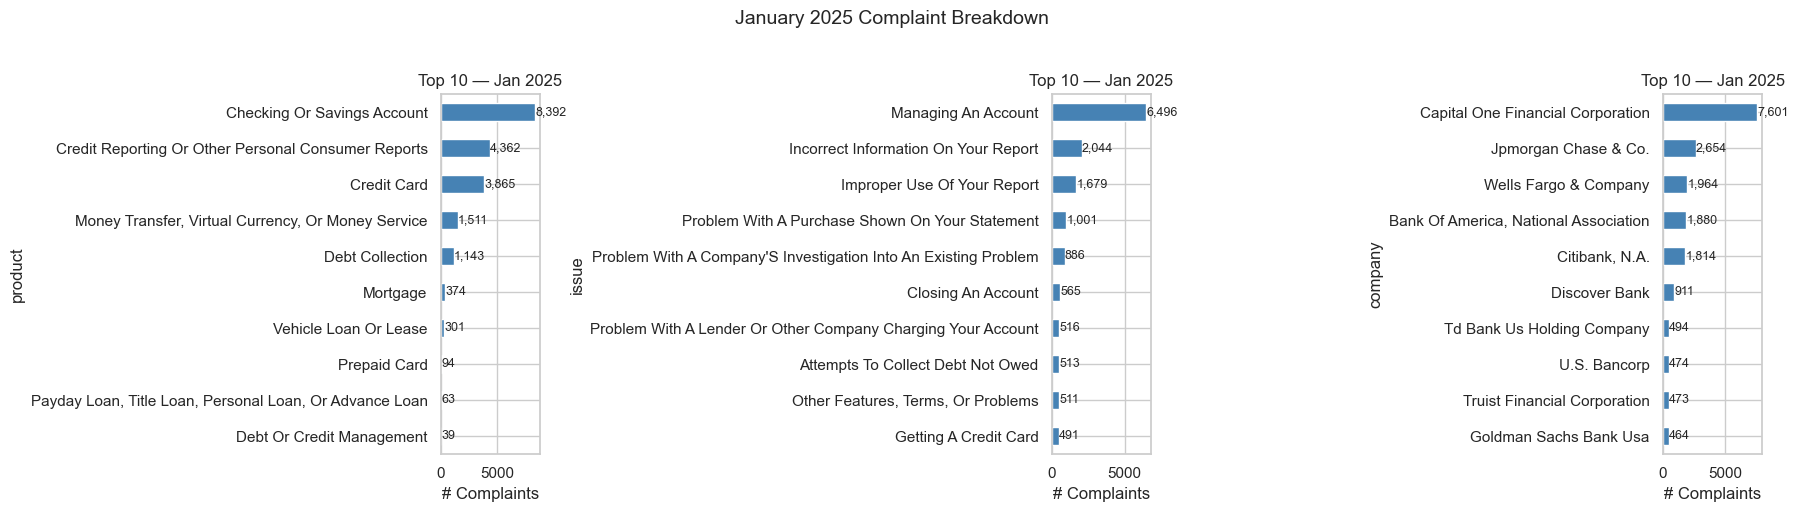

In [ ]:
jan_df = df[
    (df["date_received"].dt.year == 2025) & (df["date_received"].dt.month == 1)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

breakdown_analysis(jan_df, "product", axes[0])
breakdown_analysis(jan_df, "issue", axes[1])
breakdown_analysis(jan_df, "company", axes[2])

plt.suptitle("January 2025 Complaint Breakdown", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##### January 2025 Spike — Root Cause Breakdown

* `Product & Issue` Checking or Savings Account (8,392) drives 42% of that month's volume, 
  with Managing an Account (6,496) as the overwhelmingly dominant issue — pointing to a 
  specific account management disruption rather than a broad-based surge.

* `Company` Capital One (7,601) is nearly 3x the next company (JPMorgan Chase, 2,654), 
  strongly suggesting this was a Capital One-specific incident, not an industry-wide event.

* `Conclusion` Treat January 2025 as an outlier in all trend analysis. Exclude or flag 
  separately when modeling complaint growth rates.

### 4.3 Multivariate

#### 4.3.1 days_to_response by Product

In [ ]:
def dot_charts(col1, col2):
    if all(c in df.columns for c in [col1, col2]):

        top10 = df[col2].value_counts().head(10).index
        plot_df = df[df[col2].isin(top10)].copy()

        fig, ax = plt.subplots(figsize=(13, 5))

        sns.boxplot(data=plot_df, x="product", y="days_to_response", ax=ax)

        ax.set_title("Days to Response by Product (Top 10 Products)")
        ax.set_xlabel("Product")
        ax.set_ylabel("Days to Response")

        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.show()

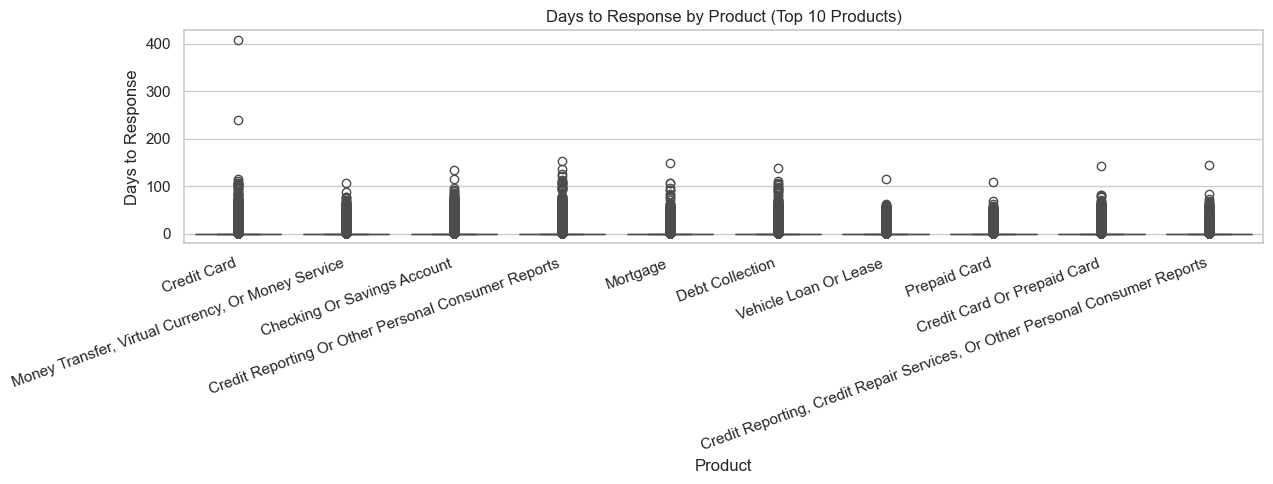

In [ ]:
dot_charts("days_to_response", "product")

##### Days to Response by Product

* **Universally fast at the median** Every product sits at or near 0 days at the median — 
  same-day forwarding to companies is the norm across the board, with no product standing 
  out as structurally slower than others.

* **Credit Card carries the most extreme outliers** With values reaching 240 and 400 days, 
  Credit Card has the longest tail by a wide margin. All other products cap out around 
  100–150 days. These extreme cases likely represent disputed or escalated complaints 
  that stalled in resolution.

* **Outliers are present in every product** No product is clean — all 10 show isolated 
  high-day outliers above their whiskers. This is a dataset-wide pattern rather than a 
  product-specific issue, reinforcing the earlier recommendation to cap or treat 
  `days_to_response` before any modeling.

#### 4.3.2 Complaint Heatmap: State × Product

* descending order

In [ ]:
def heatmap(col1, col2):
    if all(c in df.columns for c in [col1, col2]):

        top_col1 = df[col1].value_counts().head(10).index
        top_col2 = df[col2].value_counts().head(8).index

        pivot = (
            df[df[col1].isin(top_col1) & df[col2].isin(top_col2)]
            .groupby([col1, col2])
            .size()
            .unstack(fill_value=0)
        )
        # Sort rows and columns descending
        pivot = pivot.sort_index(ascending=False)
        pivot = pivot.sort_index(axis=1, ascending=False)
        fig, ax = plt.subplots(figsize=(14, 6))

        sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt="d", linewidths=0.3, ax=ax)

        ax.set_title(f"Complaint Count: {col1} × {col2}")
        plt.tight_layout()
        plt.show()

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_3946/2826315114.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


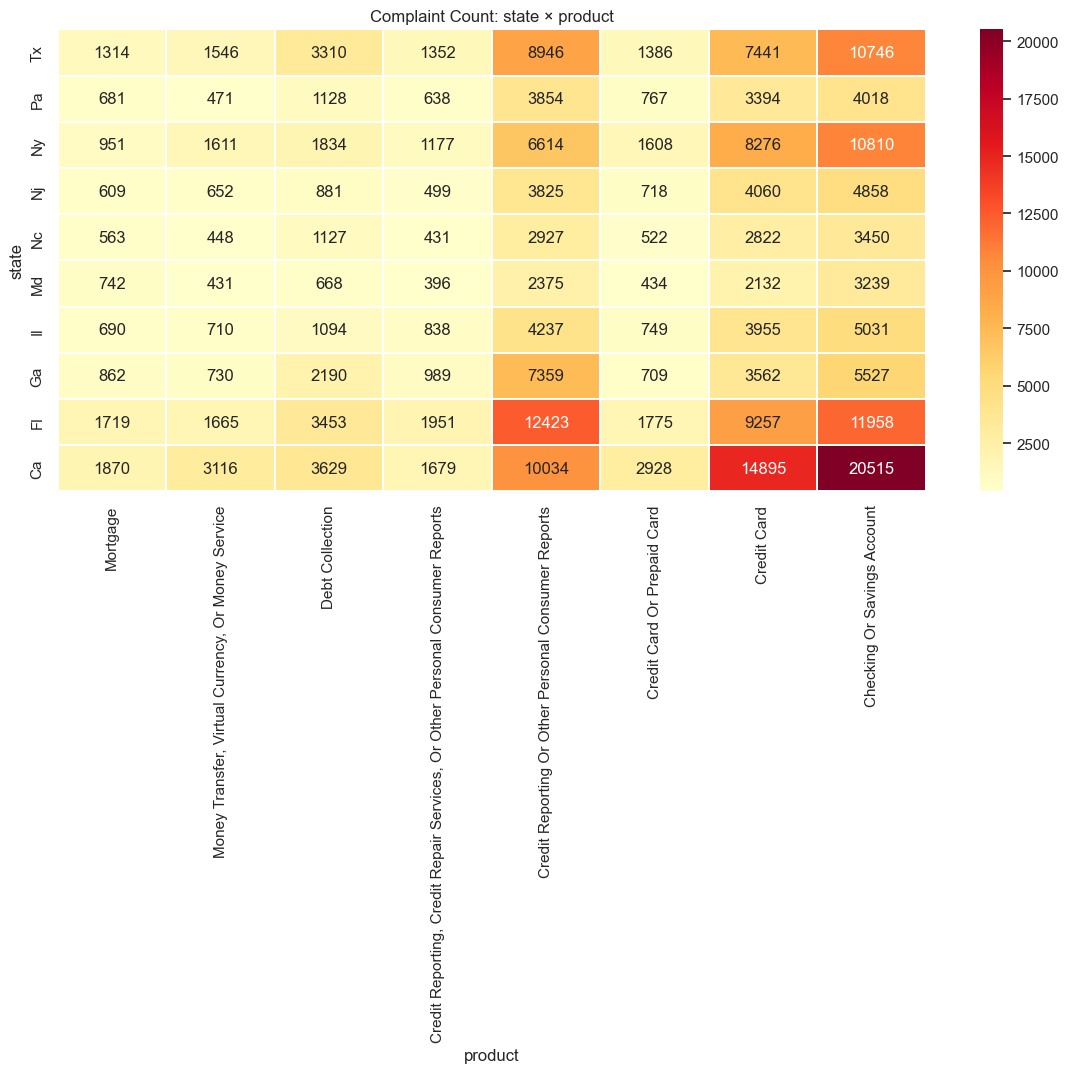

In [ ]:
heatmap("state", "product")

##### Complaint Count: State x Product

* **CA and FL dominate** California peaks at 20,515 (Checking) and 14,895 (Credit Card); 
  Florida follows consistently. Volume is population-driven but the magnitude warrants 
  state-specific attention.

* **Checking, Credit Card, and Credit Reporting are the heat sources** The three rightmost 
  columns are darkest across all states — complaint concentration is consistent regardless 
  of geography.

* **Mortgage and Money Transfer are uniformly low** Pale yellow across every state — no 
  geographic concentration, no outliers. Do not warrant state-level segmentation.

/var/folders/bf/1sjsjmcd4_j9q1b0h29g2crr0000gn/T/ipykernel_3946/2826315114.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


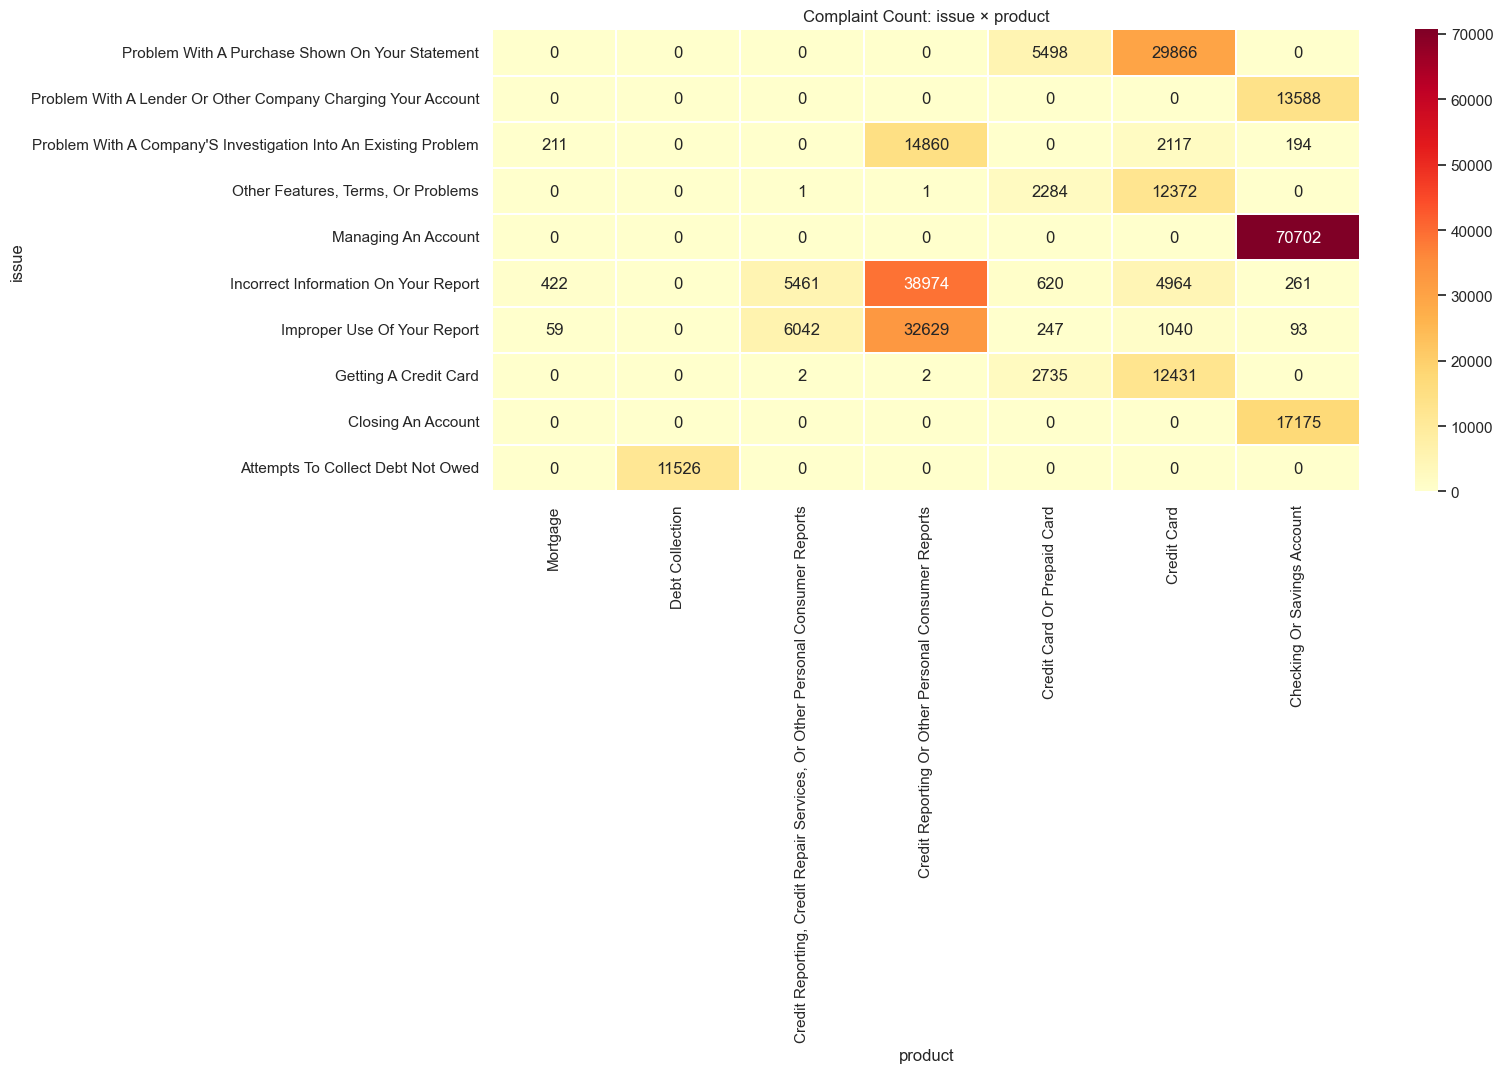

In [ ]:
heatmap("issue", "product")

##### Complaint Count: Issue x Product

* **Issues map exclusively to one product** The matrix is mostly zeros — each issue belongs 
  to a single product. No meaningful cross-product complaint patterns exist.

* **Three cells dominate** Managing an Account × Checking (70,702), Incorrect Information × 
  Credit Reporting (38,974), and Improper Use × Credit Reporting (32,629) drive the majority 
  of total volume. Resolving these three pairs addresses most of the complaint landscape.

* **Debt Collection is single-issue** Attempts to Collect Debt Not Owed accounts for 
  virtually all its volume (11,526) — straightforward to address in isolation.

# Clean dataframe summary

In [ ]:
print("=== Final Cleaned DataFrame ===")
print(f"  Shape          : {df.shape}")
print(f"  Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(
    f"  Date range     : {df['date_received'].min()} → {df['date_received'].max()}"
    if "date_received" in df.columns
    else ""
)
print(f"  Total nulls    : {df.isnull().sum().sum():,}")
print(f"  Duplicate rows : {df.duplicated().sum()}")

=== Final Cleaned DataFrame ===
  Shape          : (415257, 36)
  Memory usage   : 800.4 MB
  Date range     : 2023-01-01 00:00:00 → 2026-02-26 00:00:00
  Total nulls    : 1,047,722
  Duplicate rows : 0
